# Notebook 07 — Selective Flagship Figures and Publication Readiness

This notebook does **two** things, and only for the strongest non-ensemble story:

1. Generates a **selective, paper-oriented figure set** rather than the full internal figure dump.
2. Runs a **publication-readiness validation** focused on the sections that matter for the flagship deterministic atlas paper.

All outputs are written to a **new dedicated directory**:

`notebooks/outputs/flagship_paper_selected/`

Within that directory, this notebook creates:
- `main_figures/`
- `appendix_figures/`
- `validation/`
- `tables/`

The main-figure target is intentionally small:
- Z500 core skill
- multivariable RMSE support
- regime-conditioned Z500 RMSE
- regime-conditioned Z500 ACC
- scale-resolved spectra
- balance diagnostics
- growth diagnostics
- blocking diagnostics



In [1]:

from pathlib import Path
import sys
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def detect_bundle_root():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd.parent.parent,
        Path("/global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass"),
    ]
    for base in candidates:
        if (base / "src" / "flagship_predictability").exists():
            return base
        if (base / "flagship_predictability_nextpass" / "src" / "flagship_predictability").exists():
            return base / "flagship_predictability_nextpass"
    raise RuntimeError("Could not detect bundle root. Run from inside the project tree or edit detect_bundle_root().")

BUNDLE_ROOT = detect_bundle_root()
SRC_ROOT = BUNDLE_ROOT / "src"
NOTEBOOK_ROOT = BUNDLE_ROOT / "notebooks"
OUTPUT_ROOT = NOTEBOOK_ROOT / "outputs/flagship_final"
SELECTED_ROOT = OUTPUT_ROOT / "flagship_paper_selected"

for p in [SRC_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("Bundle root:", BUNDLE_ROOT)
print("Output root:", OUTPUT_ROOT)
print("Selected flagship directory:", SELECTED_ROOT)

for sub in ["main_figures", "appendix_figures", "validation", "tables"]:
    (SELECTED_ROOT / sub).mkdir(parents=True, exist_ok=True)

SELECTED_ROOT


Bundle root: /global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass
Output root: /global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass/notebooks/outputs/flagship_final
Selected flagship directory: /global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass/notebooks/outputs/flagship_final/flagship_paper_selected


PosixPath('/global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass/notebooks/outputs/flagship_final/flagship_paper_selected')

In [2]:

def read_csv(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Failed reading {path}: {e}")
        return pd.DataFrame()

def td_days(series):
    return pd.to_timedelta(series).dt.total_seconds() / 86400.0

def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 170,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.titlesize": 13,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "lines.linewidth": 2.0,
        "lines.markersize": 5,
    })

def save_fig(fig, outdir: Path, stem: str, manifest: list, caption: str, tier: str):
    outdir.mkdir(parents=True, exist_ok=True)
    png = outdir / f"{stem}.png"
    pdf = outdir / f"{stem}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)
    manifest.append({
        "tier": tier,
        "figure_stem": stem,
        "png_path": str(png),
        "pdf_path": str(pdf),
        "caption": caption,
    })

set_pub_style()

paths = {
    "alignment_audit": OUTPUT_ROOT / "audit" / "alignment_audit.csv",
    "regime_labels": OUTPUT_ROOT / "regimes" / "regime_labels.csv",
    "regime_sensitivity": OUTPUT_ROOT / "regimes" / "regime_sensitivity.csv",
    "det_summary": OUTPUT_ROOT / "deterministic" / "deterministic_summary.csv",
    "regime_metrics": OUTPUT_ROOT / "deterministic" / "regime_conditioned_metrics.csv",
    "spectral": OUTPUT_ROOT / "deterministic" / "spectral_diagnostics.csv",
    "balance": OUTPUT_ROOT / "deterministic" / "balance_diagnostics.csv",
    "var_avail": OUTPUT_ROOT / "deterministic" / "variable_availability.csv",
    "det_errors": OUTPUT_ROOT / "deterministic" / "deterministic_errors.csv",
    "growth": OUTPUT_ROOT / "growth" / "growth_metrics.csv",
    "growth_thr": OUTPUT_ROOT / "growth" / "growth_threshold_times.csv",
    "growth_err": OUTPUT_ROOT / "growth" / "growth_errors.csv",
    "blocking_evt": OUTPUT_ROOT / "blocking" / "blocking_event_metrics.csv",
    "blocking_rmse": OUTPUT_ROOT / "blocking" / "blocking_rmse.csv",
    "blocking_thr": OUTPUT_ROOT / "blocking" / "blocking_threshold_sweep.csv",
}

data = {k: read_csv(v) for k, v in paths.items()}
{k: df.shape for k, df in data.items()}


{'alignment_audit': (76, 7),
 'regime_labels': (364, 3),
 'regime_sensitivity': (48, 7),
 'det_summary': (48, 9),
 'regime_metrics': (768, 12),
 'spectral': (1620, 7),
 'balance': (12, 5),
 'var_avail': (12, 6),
 'det_errors': (0, 0),
 'growth': (48, 7),
 'growth_thr': (6, 6),
 'growth_err': (0, 0),
 'blocking_evt': (24, 14),
 'blocking_rmse': (12, 7),
 'blocking_thr': (60, 6)}

In [3]:

manifest = []
main_dir = SELECTED_ROOT / "main_figures"
app_dir = SELECTED_ROOT / "appendix_figures"

# Figure 1: Z500 core skill
det = data["det_summary"].copy()
if not det.empty and {"variable", "model", "lead", "rmse_mean", "acc_mean"}.issubset(det.columns):
    sub = det[det["variable"] == "z500"].copy()
    if not sub.empty:
        sub["lead_days"] = td_days(sub["lead"])
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), squeeze=False)
        ax = axes[0, 0]
        for model in sorted(sub["model"].unique()):
            ss = sub[sub["model"] == model].sort_values("lead_days")
            ax.plot(ss["lead_days"], ss["rmse_mean"], marker="o", label=model)
        ax.set_title("Z500 deterministic RMSE")
        ax.set_xlabel("Lead (days)")
        ax.set_ylabel("Area-weighted RMSE")
        ax.legend(frameon=False)

        ax = axes[0, 1]
        for model in sorted(sub["model"].unique()):
            ss = sub[sub["model"] == model].sort_values("lead_days")
            ax.plot(ss["lead_days"], ss["acc_mean"], marker="o", label=model)
        ax.set_title("Z500 anomaly correlation")
        ax.set_xlabel("Lead (days)")
        ax.set_ylabel("ACC")
        ax.set_ylim(max(0, sub["acc_mean"].min() - 0.05), 1.02)
        ax.legend(frameon=False)

        fig.suptitle("Flagship core skill: Z500", y=1.02)
        save_fig(fig, main_dir, "fig01_z500_core_skill", manifest,
                 "Main flagship skill comparison for Z500 using RMSE and anomaly correlation across lead time.",
                 "main")

# Figure 2: Multivariable RMSE support
if not det.empty and {"variable", "model", "lead", "rmse_mean"}.issubset(det.columns):
    vars_keep = [v for v in ["t850", "u850", "v850"] if v in set(det["variable"])]
    if vars_keep:
        fig, axes = plt.subplots(1, len(vars_keep), figsize=(4.6 * len(vars_keep), 4.0), squeeze=False, sharex=True)
        for ax, variable in zip(axes.ravel(), vars_keep):
            sub = det[det["variable"] == variable].copy()
            sub["lead_days"] = td_days(sub["lead"])
            for model in sorted(sub["model"].unique()):
                ss = sub[sub["model"] == model].sort_values("lead_days")
                ax.plot(ss["lead_days"], ss["rmse_mean"], marker="o", label=model)
            ax.set_title(variable.upper())
            ax.set_xlabel("Lead (days)")
            ax.set_ylabel("RMSE")
        handles, labels = axes.ravel()[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", ncol=min(3, len(labels)), frameon=False)
        fig.suptitle("Support variables: deterministic RMSE", y=1.08)
        save_fig(fig, main_dir, "fig02_multivariable_rmse_support", manifest,
                 "Support-variable RMSE comparison for T850, U850, and V850 across deterministic models.",
                 "main")

# Figure 3 and 4: Z500 regime-conditioned RMSE and ACC
regm = data["regime_metrics"].copy()
if not regm.empty and {"variable", "metric", "model", "lead", "regime", "mean"}.issubset(regm.columns):
    regm["lead_days"] = td_days(regm["lead"])
    for metric, stem, ylabel in [("RMSE", "fig03_z500_regime_rmse", "RMSE"),
                                 ("ACC", "fig04_z500_regime_acc", "ACC")]:
        sub = regm[(regm["variable"] == "z500") & (regm["metric"] == metric)].copy()
        if sub.empty:
            continue
        models = sorted(sub["model"].unique())
        fig, axes = plt.subplots(len(models), 1, figsize=(8.3, max(3.2, 2.7 * len(models))), squeeze=False, sharex=True)
        for ax, model in zip(axes.ravel(), models):
            sm = sub[sub["model"] == model].copy()
            for regime in sorted(sm["regime"].dropna().unique()):
                ss = sm[sm["regime"] == regime].sort_values("lead_days")
                ax.plot(ss["lead_days"], ss["mean"], marker="o", label=f"Regime {int(regime)}")
                if {"ci_lo", "ci_hi"}.issubset(ss.columns):
                    ax.fill_between(ss["lead_days"], ss["ci_lo"], ss["ci_hi"], alpha=0.18)
            ax.set_title(model)
            ax.set_ylabel(ylabel)
            ax.legend(frameon=False, ncol=min(4, sm["regime"].nunique()))
        axes.ravel()[-1].set_xlabel("Lead (days)")
        fig.suptitle(f"Z500 {metric} conditioned on circulation regime", y=1.02)
        save_fig(fig, main_dir, stem, manifest,
                 f"Regime-conditioned Z500 {metric} across lead time with bootstrap uncertainty bands.",
                 "main")

# Figure 5: Spectral summary
spec = data["spectral"].copy()
if not spec.empty and {"variable", "model", "lead", "wavenumber", "spectral_retention", "spectral_rmse"}.issubset(spec.columns):
    sub = spec[spec["variable"] == "z500"].copy()
    if not sub.empty:
        sub["lead_days"] = td_days(sub["lead"])
        long_lead = sub["lead_days"].max()
        short_lead = sub["lead_days"].min()
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), squeeze=False)
        ax = axes[0, 0]
        for model in sorted(sub["model"].unique()):
            ss = sub[(sub["model"] == model) & (sub["lead_days"] == long_lead)].sort_values("wavenumber")
            ax.plot(ss["wavenumber"], ss["spectral_retention"], label=model)
        ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")
        ax.set_title(f"Spectral retention at {long_lead:g}-day lead")
        ax.set_xlabel("Wavenumber")
        ax.set_ylabel("Forecast / truth spectrum")

        ax = axes[0, 1]
        for model in sorted(sub["model"].unique()):
            ss = sub[(sub["model"] == model) & (sub["lead_days"] == long_lead)].sort_values("wavenumber")
            ax.plot(ss["wavenumber"], ss["spectral_rmse"], label=model)
        ax.set_title(f"Spectral RMSE at {long_lead:g}-day lead")
        ax.set_xlabel("Wavenumber")
        ax.set_ylabel("Spectral RMSE")
        ax.legend(frameon=False)

        fig.suptitle("Scale-resolved Z500 diagnostics", y=1.02)
        save_fig(fig, main_dir, "fig05_z500_spectral_summary", manifest,
                 "Scale-resolved Z500 diagnostics showing spectral retention and spectral RMSE at the longest lead.",
                 "main")

# Figure 6: Balance diagnostics
bal = data["balance"].copy()
if not bal.empty and {"model", "lead", "div_rmse_mean", "vort_rmse_mean"}.issubset(bal.columns):
    bal["lead_days"] = td_days(bal["lead"])
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), squeeze=False)
    for ax, metric, title, ylabel in [
        (axes[0, 0], "div_rmse_mean", "Divergence RMSE", "Divergence RMSE"),
        (axes[0, 1], "vort_rmse_mean", "Vorticity RMSE", "Vorticity RMSE"),
    ]:
        for model in sorted(bal["model"].unique()):
            ss = bal[bal["model"] == model].sort_values("lead_days")
            ax.plot(ss["lead_days"], ss[metric], marker="o", label=model)
        ax.set_title(title)
        ax.set_xlabel("Lead (days)")
        ax.set_ylabel(ylabel)
    axes[0, 1].legend(frameon=False)
    fig.suptitle("Pole-safe balance diagnostics", y=1.02)
    save_fig(fig, main_dir, "fig06_balance_diagnostics", manifest,
             "Pole-safe divergence and vorticity RMSE across lead time for the deterministic models.",
             "main")

# Figure 7: Growth diagnostics
gr = data["growth"].copy()
if not gr.empty and {"model", "lead", "mean_lagged_growth", "mean_error_growth"}.issubset(gr.columns):
    gr["lead_days"] = td_days(gr["lead"])
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), squeeze=False)
    for ax, metric, title, ylabel in [
        (axes[0, 0], "mean_lagged_growth", "Lagged forecast separation growth", "Lagged growth"),
        (axes[0, 1], "mean_error_growth", "Forecast error growth", "Error growth"),
    ]:
        for model in sorted(gr["model"].unique()):
            ss = gr[gr["model"] == model].sort_values("lead_days")
            ax.plot(ss["lead_days"], ss[metric], marker="o", label=model)
        ax.set_title(title)
        ax.set_xlabel("Lead (days)")
        ax.set_ylabel(ylabel)
    axes[0, 1].legend(frameon=False)
    fig.suptitle("Predictability-growth diagnostics", y=1.02)
    save_fig(fig, main_dir, "fig07_growth_diagnostics", manifest,
             "Lagged-growth and forecast-error-growth diagnostics for deterministic models.",
             "main")

# Figure 8: Blocking summary
bthr = data["blocking_thr"].copy()
brmse = data["blocking_rmse"].copy()
bevt = data["blocking_evt"].copy()
if not bthr.empty and not brmse.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4), squeeze=False)

    ax = axes[0, 0]
    if {"threshold", "fraction_truth_blocked"}.issubset(bthr.columns):
        group_cols = ["threshold"]
        if "sector" in bthr.columns:
            for sector in sorted(bthr["sector"].dropna().unique()):
                ss = bthr[bthr["sector"] == sector].groupby("threshold", as_index=False)["fraction_truth_blocked"].mean()
                ax.plot(ss["threshold"], ss["fraction_truth_blocked"], marker="o", label=str(sector))
        else:
            ss = bthr.groupby("threshold", as_index=False)["fraction_truth_blocked"].mean()
            ax.plot(ss["threshold"], ss["fraction_truth_blocked"], marker="o")
        ax.set_title("Truth-blocked fraction vs threshold")
        ax.set_xlabel("Blocking threshold")
        ax.set_ylabel("Fraction truth blocked")
        if "sector" in bthr.columns:
            ax.legend(frameon=False)

    ax = axes[0, 1]
    plot_df = brmse.copy()
    if "lead" in plot_df.columns:
        plot_df["lead_days"] = td_days(plot_df["lead"])
        target = 5.0 if np.any(np.isclose(plot_df["lead_days"], 5.0)) else plot_df["lead_days"].max()
        plot_df = plot_df[np.isclose(plot_df["lead_days"], target)]
    if not plot_df.empty and {"model", "blocked_rmse", "unblocked_rmse"}.issubset(plot_df.columns):
        x = np.arange(len(plot_df["model"]))
        width = 0.38
        ax.bar(x - width/2, plot_df["blocked_rmse"].fillna(0), width=width, label="Blocked")
        ax.bar(x + width/2, plot_df["unblocked_rmse"].fillna(0), width=width, label="Unblocked")
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df["model"])
        ax.set_title(f"Blocked vs unblocked RMSE at {target:g}-day lead")
        ax.set_ylabel("RMSE")
        ax.legend(frameon=False)

    fig.suptitle("Blocking diagnostics", y=1.03)
    save_fig(fig, main_dir, "fig08_blocking_summary", manifest,
             "Blocking-threshold sensitivity and blocked-vs-unblocked RMSE for the deterministic atlas.",
             "main")

# Appendix figure A1: regime fractions
labels = data["regime_labels"].copy()
if not labels.empty and {"regime"}.issubset(labels.columns):
    if "window" not in labels.columns:
        labels["window"] = "main"
    frac = labels.groupby(["window", "regime"]).size().reset_index(name="count")
    frac["fraction"] = frac["count"] / frac.groupby("window")["count"].transform("sum")
    fig, axes = plt.subplots(len(frac["window"].unique()), 1, figsize=(7.0, max(3.2, 2.8 * frac["window"].nunique())), squeeze=False)
    for ax, window in zip(axes.ravel(), frac["window"].unique()):
        ss = frac[frac["window"] == window].sort_values("regime")
        ax.bar(ss["regime"].astype(str), ss["fraction"])
        ax.set_title(f"Regime occupancy: {window}")
        ax.set_xlabel("Regime")
        ax.set_ylabel("Fraction")
    save_fig(fig, app_dir, "figA1_regime_fractions", manifest,
             "Appendix figure showing regime occupancy fractions for each evaluated window.",
             "appendix")

# Appendix figure A2: regime sensitivity
rs = data["regime_sensitivity"].copy()
if not rs.empty and {"n_components", "n_regimes", "fraction"}.issubset(rs.columns):
    fig, ax = plt.subplots(figsize=(7.6, 4.4))
    for nreg in sorted(rs["n_regimes"].unique()):
        sub = rs[rs["n_regimes"] == nreg].groupby("n_components")["fraction"].agg(["min", "max"]).reset_index()
        ax.plot(sub["n_components"], sub["min"], marker="o", label=f"{int(nreg)} regimes: min fraction")
        ax.plot(sub["n_components"], sub["max"], marker="s", linestyle="--", label=f"{int(nreg)} regimes: max fraction")
    ax.set_title("Regime-balance sensitivity")
    ax.set_xlabel("EOF components")
    ax.set_ylabel("Cluster fraction")
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, ncol=2)
    save_fig(fig, app_dir, "figA2_regime_sensitivity", manifest,
             "Appendix figure showing how regime occupancy changes with EOF-component count and regime count.",
             "appendix")

manifest_df = pd.DataFrame(manifest)
manifest_path = SELECTED_ROOT / "tables" / "selected_figure_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)
manifest_path


PosixPath('/global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass/notebooks/outputs/flagship_final/flagship_paper_selected/tables/selected_figure_manifest.csv')

In [4]:

def status_rank(status: str) -> int:
    return {"FAIL": 0, "WARN": 1, "PASS": 2}.get(status, -1)

rows = []

def record(test_name, status, criterion, evidence, action):
    rows.append({
        "test_name": test_name,
        "status": status,
        "criterion": criterion,
        "evidence": evidence,
        "recommended_action": action,
    })

# 1. Alignment
align = data["alignment_audit"]
if align.empty:
    record("audit_alignment", "FAIL",
           "alignment_audit.csv should exist and contain aligned forecast-truth checks.",
           "alignment_audit.csv missing or empty.",
           "Rerun Notebook 00.")
else:
    non_ok = align[align["status"] != "ok"] if "status" in align.columns else pd.DataFrame()
    if non_ok.empty:
        record("audit_alignment", "PASS",
               "All forecast-truth alignment checks should report status=ok.",
               f"All {len(align)} audited rows reported status=ok.",
               "No action needed.")
    else:
        record("audit_alignment", "WARN",
               "All forecast-truth alignment checks should report status=ok.",
               f"Found {len(non_ok)} non-ok rows.",
               "Fix the non-ok combinations before using them in the paper.")

# 2. Regime balance
labels = data["regime_labels"]
if labels.empty or "regime" not in labels.columns:
    record("regime_balance", "FAIL",
           "Main regime-label file should be non-empty and contain regime labels.",
           "regime_labels.csv missing or empty.",
           "Rerun Notebook 01.")
else:
    frac = labels["regime"].value_counts(normalize=True).sort_index()
    minf, maxf = float(frac.min()), float(frac.max())
    if minf >= 0.10 and maxf <= 0.50:
        record("regime_balance", "PASS",
               "No regime should be too small or overwhelmingly dominant in the main setup.",
               f"Regime fractions={dict((int(k), round(v, 3)) for k, v in frac.items())}.",
               "No action needed.")
    elif minf >= 0.06 and maxf <= 0.60:
        record("regime_balance", "WARN",
               "No regime should be too small or overwhelmingly dominant in the main setup.",
               f"Regime fractions={dict((int(k), round(v, 3)) for k, v in frac.items())}.",
               "Keep the regime-balance figure in the appendix and soften claims about regime exclusivity.")
    else:
        record("regime_balance", "FAIL",
               "No regime should be too small or overwhelmingly dominant in the main setup.",
               f"Regime fractions={dict((int(k), round(v, 3)) for k, v in frac.items())}.",
               "Reduce regime count or broaden the training window.")

# 3. Regime stability (stricter than internal notebook)
rs = data["regime_sensitivity"]
if rs.empty:
    record("regime_stability", "FAIL",
           "A flagship paper needs a regime-sensitivity table.",
           "regime_sensitivity.csv missing or empty.",
           "Rerun Notebook 03.")
else:
    subset = rs[rs["n_regimes"] == 4].copy()
    if subset.empty:
        record("regime_stability", "FAIL",
               "A flagship paper needs a 4-regime robustness section if 4 regimes are the main setting.",
               "No 4-regime rows found.",
               "Rerun Notebook 03 with n_regimes=4 in the grid.")
    else:
        spread_rows = []
        for _, grp in subset.groupby("n_components"):
            fracs = np.sort(grp["fraction"].to_numpy(dtype=float))
            spread_rows.append(fracs)
        mat = np.vstack(spread_rows) if spread_rows else np.empty((0,))
        max_range = float(np.nanmax(mat, axis=0).max() - np.nanmin(mat, axis=0).min()) if mat.size else np.nan
        min_cluster = float(subset["fraction"].min())
        if min_cluster >= 0.08 and max_range <= 0.15:
            status = "PASS"
            action = "No action needed."
        elif min_cluster >= 0.05 and max_range <= 0.22:
            status = "WARN"
            action = "Keep regime sensitivity in the appendix and avoid claiming regime uniqueness too strongly."
        else:
            status = "FAIL"
            action = ("For absolute flagship level, retrain regimes on a longer climatological window, "
                      "keep 4 regimes as main, and show 3-regime robustness in the paper.")
        record("regime_stability", status,
               "Sorted cluster fractions should not vary wildly across EOF-count choices.",
               f"Minimum cluster fraction={min_cluster:.3f}; max spread in sorted fractions={max_range:.3f}.",
               action)

# 4. Deterministic core completeness
det = data["det_summary"]
if det.empty:
    record("deterministic_core", "FAIL",
           "deterministic_summary.csv should exist and contain model-variable-lead rows.",
           "deterministic_summary.csv missing or empty.",
           "Rerun Notebook 02.")
else:
    required_vars = {"z500", "t850", "u850", "v850"}
    have_vars = set(det["variable"].unique()) if "variable" in det.columns else set()
    missing_req = sorted(required_vars - have_vars)
    lead_counts = int(det.groupby(["model", "variable"])["lead"].nunique().min()) if {"model","variable","lead"}.issubset(det.columns) else 0
    if not missing_req and lead_counts >= 4:
        record("deterministic_core", "PASS",
               "Core deterministic variables should be present for all models across the headline leads.",
               f"Variables present={sorted(have_vars)}; minimum lead count per model-variable={lead_counts}.",
               "No action needed.")
    else:
        record("deterministic_core", "FAIL",
               "Core deterministic variables should be present for all models across the headline leads.",
               f"Missing required vars={missing_req}; minimum lead count per model-variable={lead_counts}.",
               "Repair model-variable coverage before using the atlas as the flagship backbone.")

# 5. Reduced-coverage variables
avail = data["var_avail"]
if avail.empty:
    record("reduced_coverage_variables", "WARN",
           "Reduced-coverage variables should be documented clearly.",
           "variable_availability.csv missing or empty.",
           "Use the patched Notebook 02 and keep optional variables out of the headline table.")
else:
    missing = avail[avail["status"] != "ok"] if "status" in avail.columns else pd.DataFrame()
    if missing.empty:
        record("reduced_coverage_variables", "PASS",
               "Optional variables should either be fully covered or documented as appendix-only.",
               "No missing-variable rows were logged.",
               "No action needed.")
    else:
        missing_vars = sorted(missing["variable"].astype(str).unique())
        status = "WARN" if set(missing_vars) <= {"mslp", "tp"} else "FAIL"
        action = ("Keep reduced-coverage variables like MSLP out of the main all-model figure set."
                  if status == "WARN" else
                  "Do not claim full variable coverage until missing variables are fixed.")
        record("reduced_coverage_variables", status,
               "Optional variables should not contaminate the headline all-model comparison.",
               f"Missing-variable rows logged for variables={missing_vars}.",
               action)

# 6. Balance diagnostics
bal = data["balance"]
if bal.empty:
    record("balance_diagnostics", "FAIL",
           "Pole-safe balance diagnostics should exist for flagship-level claims.",
           "balance_diagnostics.csv missing or empty.",
           "Use the pole-safe patch and rerun Notebook 02.")
else:
    vals = pd.concat([bal["div_rmse_mean"], bal["vort_rmse_mean"]], axis=0).astype(float)
    finite = np.isfinite(vals).all()
    vmax = float(np.nanmax(vals)) if len(vals) else np.nan
    if finite and vmax < 1e6:
        record("balance_diagnostics", "PASS",
               "Balance diagnostics should be finite and free of obvious pole singularities.",
               f"Finite={finite}; max balance metric={vmax:.3e}.",
               "No action needed.")
    elif finite and vmax < 1e9:
        record("balance_diagnostics", "WARN",
               "Balance diagnostics should be finite and free of obvious pole singularities.",
               f"Finite={finite}; max balance metric={vmax:.3e}.",
               "Visually inspect the balance figure before calling it flagship-ready.")
    else:
        record("balance_diagnostics", "FAIL",
               "Balance diagnostics should be finite and free of obvious pole singularities.",
               f"Finite={finite}; max balance metric={vmax:.3e}.",
               "Do not use the balance section until the pole-safe fix is verified.")

# 7. Spectral diagnostics
spec = data["spectral"]
if spec.empty:
    record("spectral_diagnostics", "FAIL",
           "Spectral diagnostics should exist for the scale-conditioned flagship section.",
           "spectral_diagnostics.csv missing or empty.",
           "Rerun Notebook 02.")
else:
    finite_frac = float(np.isfinite(spec["spectral_retention"]).mean()) if "spectral_retention" in spec.columns else 0.0
    neg_frac = float((spec["spectral_retention"] < -0.1).mean()) if "spectral_retention" in spec.columns else 1.0
    if finite_frac >= 0.98 and neg_frac == 0.0:
        record("spectral_diagnostics", "PASS",
               "Spectral-retention curves should be finite and physically interpretable.",
               f"Finite fraction={finite_frac:.3f}; fraction below -0.1 = {neg_frac:.3f}.",
               "No action needed.")
    else:
        record("spectral_diagnostics", "WARN",
               "Spectral-retention curves should be finite and physically interpretable.",
               f"Finite fraction={finite_frac:.3f}; fraction below -0.1 = {neg_frac:.3f}.",
               "Inspect suspicious long-wave or near-Nyquist behavior before final submission.")

# 8. Growth diagnostics
gr = data["growth"]
gerr = data["growth_err"]
if gr.empty:
    record("growth_diagnostics", "FAIL",
           "growth_metrics.csv should be populated for deterministic growth analysis.",
           "growth_metrics.csv missing or empty.",
           "Use the patched Notebook 04 and rerun.")
else:
    lead_counts = gr.groupby("model")["lead"].nunique().to_dict() if {"model","lead"}.issubset(gr.columns) else {}
    full = min(lead_counts.values()) >= 4 if lead_counts else False
    if full and (gerr.empty or len(gerr) == 0):
        record("growth_diagnostics", "PASS",
               "Each deterministic model should populate all headline growth leads without workflow errors.",
               f"Lead counts by model={lead_counts}; growth errors={len(gerr)}.",
               "No action needed.")
    elif full:
        record("growth_diagnostics", "WARN",
               "Each deterministic model should populate all headline growth leads without workflow errors.",
               f"Lead counts by model={lead_counts}; growth errors={len(gerr)}.",
               "Inspect growth_errors.csv and confirm the surviving outputs remain complete.")
    else:
        record("growth_diagnostics", "FAIL",
               "Each deterministic model should populate all headline growth leads without workflow errors.",
               f"Lead counts by model={lead_counts}; growth errors={len(gerr)}.",
               "Fix time-axis alignment before publication.")

# 9. Blocking diagnostics
bevt = data["blocking_evt"]
brmse = data["blocking_rmse"]
bthr = data["blocking_thr"]
if bevt.empty:
    record("blocking_diagnostics", "FAIL",
           "Blocking verification outputs should contain a nontrivial truth-event sample.",
           "blocking_event_metrics.csv missing or empty.",
           "Rerun Notebook 05 with the threshold sweep enabled.")
else:
    truth_pos = float(bevt.get("truth_positive_count", pd.Series(dtype=float)).fillna(0).sum()) if "truth_positive_count" in bevt.columns else 0.0
    blocked_rows = float(brmse.get("n_blocked", pd.Series(dtype=float)).fillna(0).sum()) if not brmse.empty else 0.0
    thr01 = 0.0
    if not bthr.empty and {"threshold", "fraction_truth_blocked"}.issubset(bthr.columns):
        sub01 = bthr[np.isclose(bthr["threshold"].astype(float), 0.1)]
        if not sub01.empty:
            thr01 = float(sub01["fraction_truth_blocked"].mean())
    if truth_pos > 10 and blocked_rows > 10:
        record("blocking_diagnostics", "PASS",
               "Blocking verification should have a nontrivial truth-event sample under the chosen threshold.",
               f"truth_positive_count sum={truth_pos:.0f}; n_blocked sum={blocked_rows:.0f}; mean truth-blocked fraction at thr=0.1 is {thr01:.3f}.",
               "No action needed.")
    elif thr01 > 0:
        record("blocking_diagnostics", "WARN",
               "Blocking verification should have a nontrivial truth-event sample under the chosen threshold.",
               f"truth_positive_count sum={truth_pos:.0f}; n_blocked sum={blocked_rows:.0f}; mean truth-blocked fraction at thr=0.1 is {thr01:.3f}.",
               "For absolute flagship level, expand the window or add a second season before submission.")
    else:
        record("blocking_diagnostics", "FAIL",
               "Blocking verification should have a nontrivial truth-event sample under the chosen threshold.",
               f"truth_positive_count sum={truth_pos:.0f}; n_blocked sum={blocked_rows:.0f}; mean truth-blocked fraction at thr=0.1 is {thr01:.3f}.",
               "Lower the threshold or broaden the window.")

# 10. Selected figures present
manifest_df = read_csv(SELECTED_ROOT / "tables" / "selected_figure_manifest.csv")
expected_main = {
    "fig01_z500_core_skill",
    "fig02_multivariable_rmse_support",
    "fig03_z500_regime_rmse",
    "fig04_z500_regime_acc",
    "fig05_z500_spectral_summary",
    "fig06_balance_diagnostics",
    "fig07_growth_diagnostics",
    "fig08_blocking_summary",
}
have = set(manifest_df["figure_stem"]) if not manifest_df.empty else set()
missing = sorted(expected_main - have)
if not missing:
    record("selected_figure_set", "PASS",
           "The flagship paper figure set should exist in a dedicated export directory.",
           f"Saved {len(manifest_df)} selected figures across main and appendix tiers.",
           "No action needed.")
else:
    record("selected_figure_set", "FAIL",
           "The flagship paper figure set should exist in a dedicated export directory.",
           f"Missing expected figures={missing}.",
           "Rerun the figure cells and inspect missing upstream outputs.")

ready_df = pd.DataFrame(rows)
overall_status = {0: "NOT READY", 1: "NEARLY READY", 2: "READY"}[ready_df["status"].map(status_rank).min()]
summary = {
    "overall_status": overall_status,
    "n_pass": int((ready_df["status"] == "PASS").sum()),
    "n_warn": int((ready_df["status"] == "WARN").sum()),
    "n_fail": int((ready_df["status"] == "FAIL").sum()),
}

val_dir = SELECTED_ROOT / "validation"
csv_path = val_dir / "publication_readiness_selected.csv"
json_path = val_dir / "publication_readiness_selected_summary.json"
md_path = val_dir / "publication_readiness_selected_summary.md"

ready_df.to_csv(csv_path, index=False)
json_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

lines = [
    "# Selective flagship publication-readiness summary",
    "",
    f"Overall status: **{overall_status}**",
    "",
    f"- PASS: {summary['n_pass']}",
    f"- WARN: {summary['n_warn']}",
    f"- FAIL: {summary['n_fail']}",
    "",
    "## Main interpretation",
    "",
    "- PASS means the section is strong enough to support the deterministic flagship paper now.",
    "- WARN means the section is usable, but should be framed cautiously or upgraded before submission.",
    "- FAIL means the section still blocks a true flagship-level claim.",
    "",
    "## Test-by-test assessment",
    "",
]
for _, row in ready_df.iterrows():
    lines.extend([
        f"### {row['test_name']} — {row['status']}",
        f"- Criterion: {row['criterion']}",
        f"- Evidence: {row['evidence']}",
        f"- Recommended action: {row['recommended_action']}",
        "",
    ])
md_path.write_text("\n".join(lines), encoding="utf-8")

(csv_path, json_path, md_path)


(PosixPath('/global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass/notebooks/outputs/flagship_final/flagship_paper_selected/validation/publication_readiness_selected.csv'),
 PosixPath('/global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass/notebooks/outputs/flagship_final/flagship_paper_selected/validation/publication_readiness_selected_summary.json'),
 PosixPath('/global/u2/s/suryact/Chaos_Theory/project1_code/flagship_predictability_nextpass/notebooks/outputs/flagship_final/flagship_paper_selected/validation/publication_readiness_selected_summary.md'))

In [5]:

print("\n--- selected_figure_manifest ---")
display(pd.read_csv(SELECTED_ROOT / "tables" / "selected_figure_manifest.csv"))

print("\n--- publication_readiness_selected ---")
display(pd.read_csv(SELECTED_ROOT / "validation" / "publication_readiness_selected.csv"))

print("\n--- publication_readiness_selected_summary.md ---")
from IPython.display import Markdown, display
display(Markdown((SELECTED_ROOT / "validation" / "publication_readiness_selected_summary.md").read_text(encoding="utf-8")))



--- selected_figure_manifest ---


,tier,figure_stem,png_path,pdf_path,caption
0,main,fig01_z500_core_skill,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Main flagship skill comparison for Z500 using ...
1,main,fig02_multivariable_rmse_support,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,"Support-variable RMSE comparison for T850, U85..."
2,main,fig03_z500_regime_rmse,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Regime-conditioned Z500 RMSE across lead time ...
3,main,fig04_z500_regime_acc,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Regime-conditioned Z500 ACC across lead time w...
4,main,fig05_z500_spectral_summary,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Scale-resolved Z500 diagnostics showing spectr...
5,main,fig06_balance_diagnostics,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Pole-safe divergence and vorticity RMSE across...
6,main,fig07_growth_diagnostics,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Lagged-growth and forecast-error-growth diagno...
7,main,fig08_blocking_summary,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Blocking-threshold sensitivity and blocked-vs-...
8,appendix,figA1_regime_fractions,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Appendix figure showing regime occupancy fract...
9,appendix,figA2_regime_sensitivity,/global/u2/s/suryact/Chaos_Theory/project1_cod...,/global/u2/s/suryact/Chaos_Theory/project1_cod...,Appendix figure showing how regime occupancy c...



--- publication_readiness_selected ---


,test_name,status,criterion,evidence,recommended_action
0,audit_alignment,WARN,All forecast-truth alignment checks should rep...,Found 20 non-ok rows.,Fix the non-ok combinations before using them ...
1,regime_balance,PASS,No regime should be too small or overwhelmingl...,"Regime fractions={0: 0.231, 1: 0.118, 2: 0.354...",No action needed.
2,regime_stability,FAIL,Sorted cluster fractions should not vary wildl...,Minimum cluster fraction=0.118; max spread in ...,"For absolute flagship level, retrain regimes o..."
3,deterministic_core,PASS,Core deterministic variables should be present...,"Variables present=['t850', 'u850', 'v850', 'z5...",No action needed.
4,reduced_coverage_variables,PASS,Optional variables should either be fully cove...,No missing-variable rows were logged.,No action needed.
5,balance_diagnostics,PASS,Balance diagnostics should be finite and free ...,Finite=True; max balance metric=2.775e-05.,No action needed.
6,spectral_diagnostics,PASS,Spectral-retention curves should be finite and...,Finite fraction=1.000; fraction below -0.1 = 0...,No action needed.
7,growth_diagnostics,PASS,Each deterministic model should populate all h...,"Lead counts by model={'GraphCast': 4, 'HRES': ...",No action needed.
8,blocking_diagnostics,PASS,Blocking verification should have a nontrivial...,truth_positive_count sum=720; n_blocked sum=63...,No action needed.
9,selected_figure_set,PASS,The flagship paper figure set should exist in ...,Saved 10 selected figures across main and appe...,No action needed.



--- publication_readiness_selected_summary.md ---


# Selective flagship publication-readiness summary

Overall status: **NOT READY**

- PASS: 8
- WARN: 1
- FAIL: 1

## Main interpretation

- PASS means the section is strong enough to support the deterministic flagship paper now.
- WARN means the section is usable, but should be framed cautiously or upgraded before submission.
- FAIL means the section still blocks a true flagship-level claim.

## Test-by-test assessment

### audit_alignment — WARN
- Criterion: All forecast-truth alignment checks should report status=ok.
- Evidence: Found 20 non-ok rows.
- Recommended action: Fix the non-ok combinations before using them in the paper.

### regime_balance — PASS
- Criterion: No regime should be too small or overwhelmingly dominant in the main setup.
- Evidence: Regime fractions={0: 0.231, 1: 0.118, 2: 0.354, 3: 0.297}.
- Recommended action: No action needed.

### regime_stability — FAIL
- Criterion: Sorted cluster fractions should not vary wildly across EOF-count choices.
- Evidence: Minimum cluster fraction=0.118; max spread in sorted fractions=0.245.
- Recommended action: For absolute flagship level, retrain regimes on a longer climatological window, keep 4 regimes as main, and show 3-regime robustness in the paper.

### deterministic_core — PASS
- Criterion: Core deterministic variables should be present for all models across the headline leads.
- Evidence: Variables present=['t850', 'u850', 'v850', 'z500']; minimum lead count per model-variable=4.
- Recommended action: No action needed.

### reduced_coverage_variables — PASS
- Criterion: Optional variables should either be fully covered or documented as appendix-only.
- Evidence: No missing-variable rows were logged.
- Recommended action: No action needed.

### balance_diagnostics — PASS
- Criterion: Balance diagnostics should be finite and free of obvious pole singularities.
- Evidence: Finite=True; max balance metric=2.775e-05.
- Recommended action: No action needed.

### spectral_diagnostics — PASS
- Criterion: Spectral-retention curves should be finite and physically interpretable.
- Evidence: Finite fraction=1.000; fraction below -0.1 = 0.000.
- Recommended action: No action needed.

### growth_diagnostics — PASS
- Criterion: Each deterministic model should populate all headline growth leads without workflow errors.
- Evidence: Lead counts by model={'GraphCast': 4, 'HRES': 4, 'NeuralGCM': 4}; growth errors=0.
- Recommended action: No action needed.

### blocking_diagnostics — PASS
- Criterion: Blocking verification should have a nontrivial truth-event sample under the chosen threshold.
- Evidence: truth_positive_count sum=720; n_blocked sum=636; mean truth-blocked fraction at thr=0.1 is 0.305.
- Recommended action: No action needed.

### selected_figure_set — PASS
- Criterion: The flagship paper figure set should exist in a dedicated export directory.
- Evidence: Saved 10 selected figures across main and appendix tiers.
- Recommended action: No action needed.


fig01_z500_core_skill.png


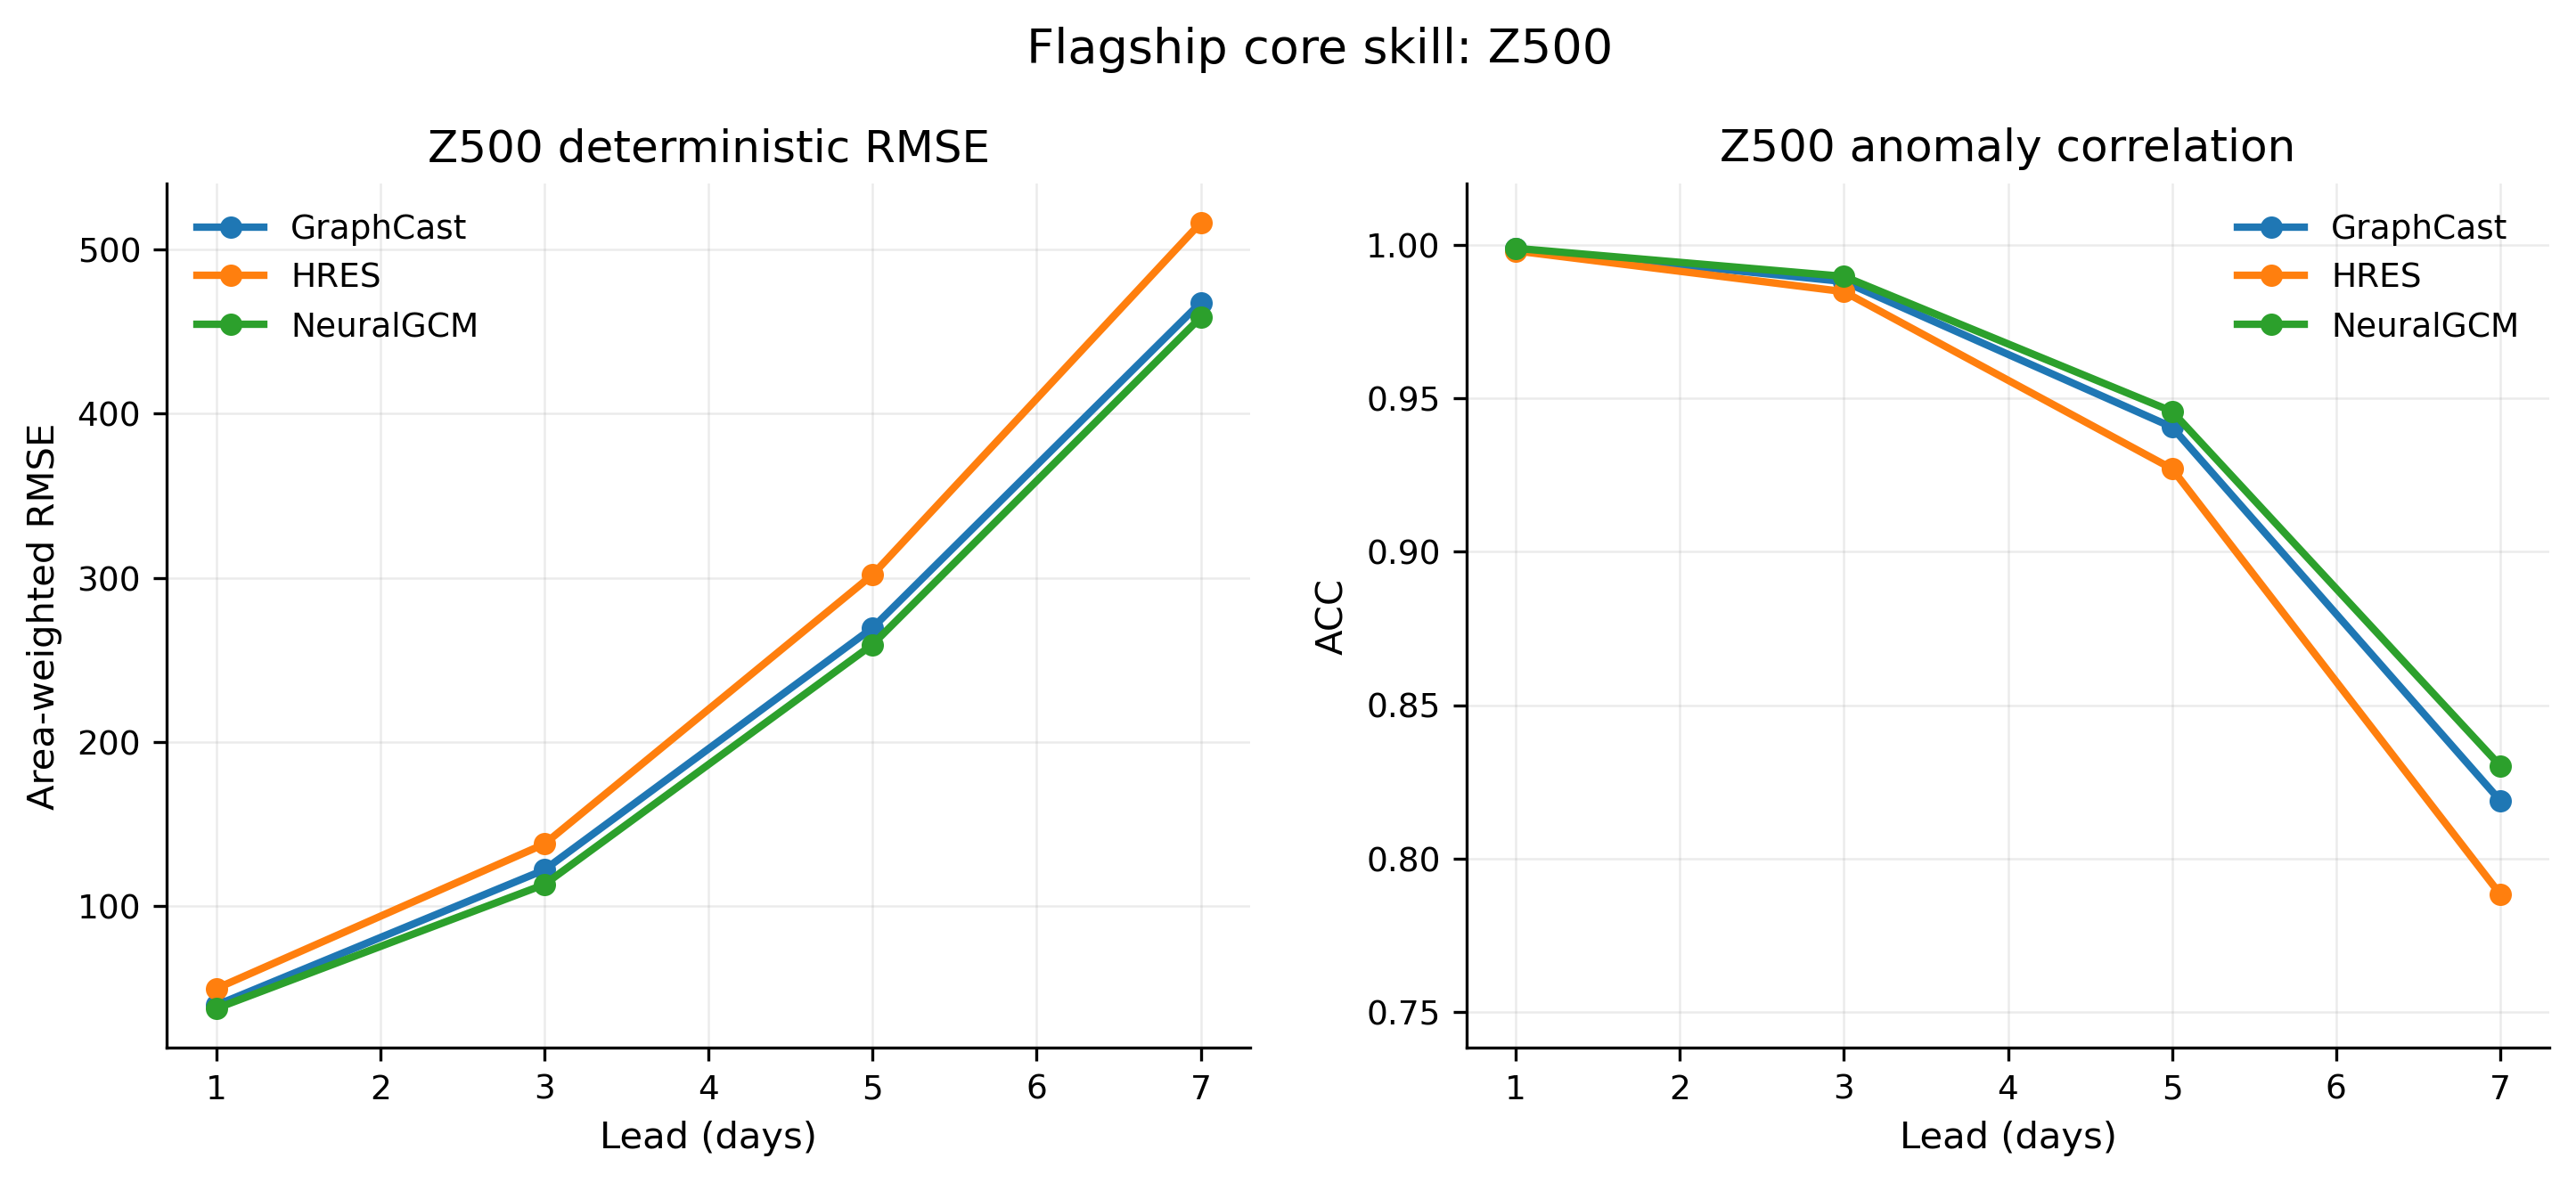

fig02_multivariable_rmse_support.png


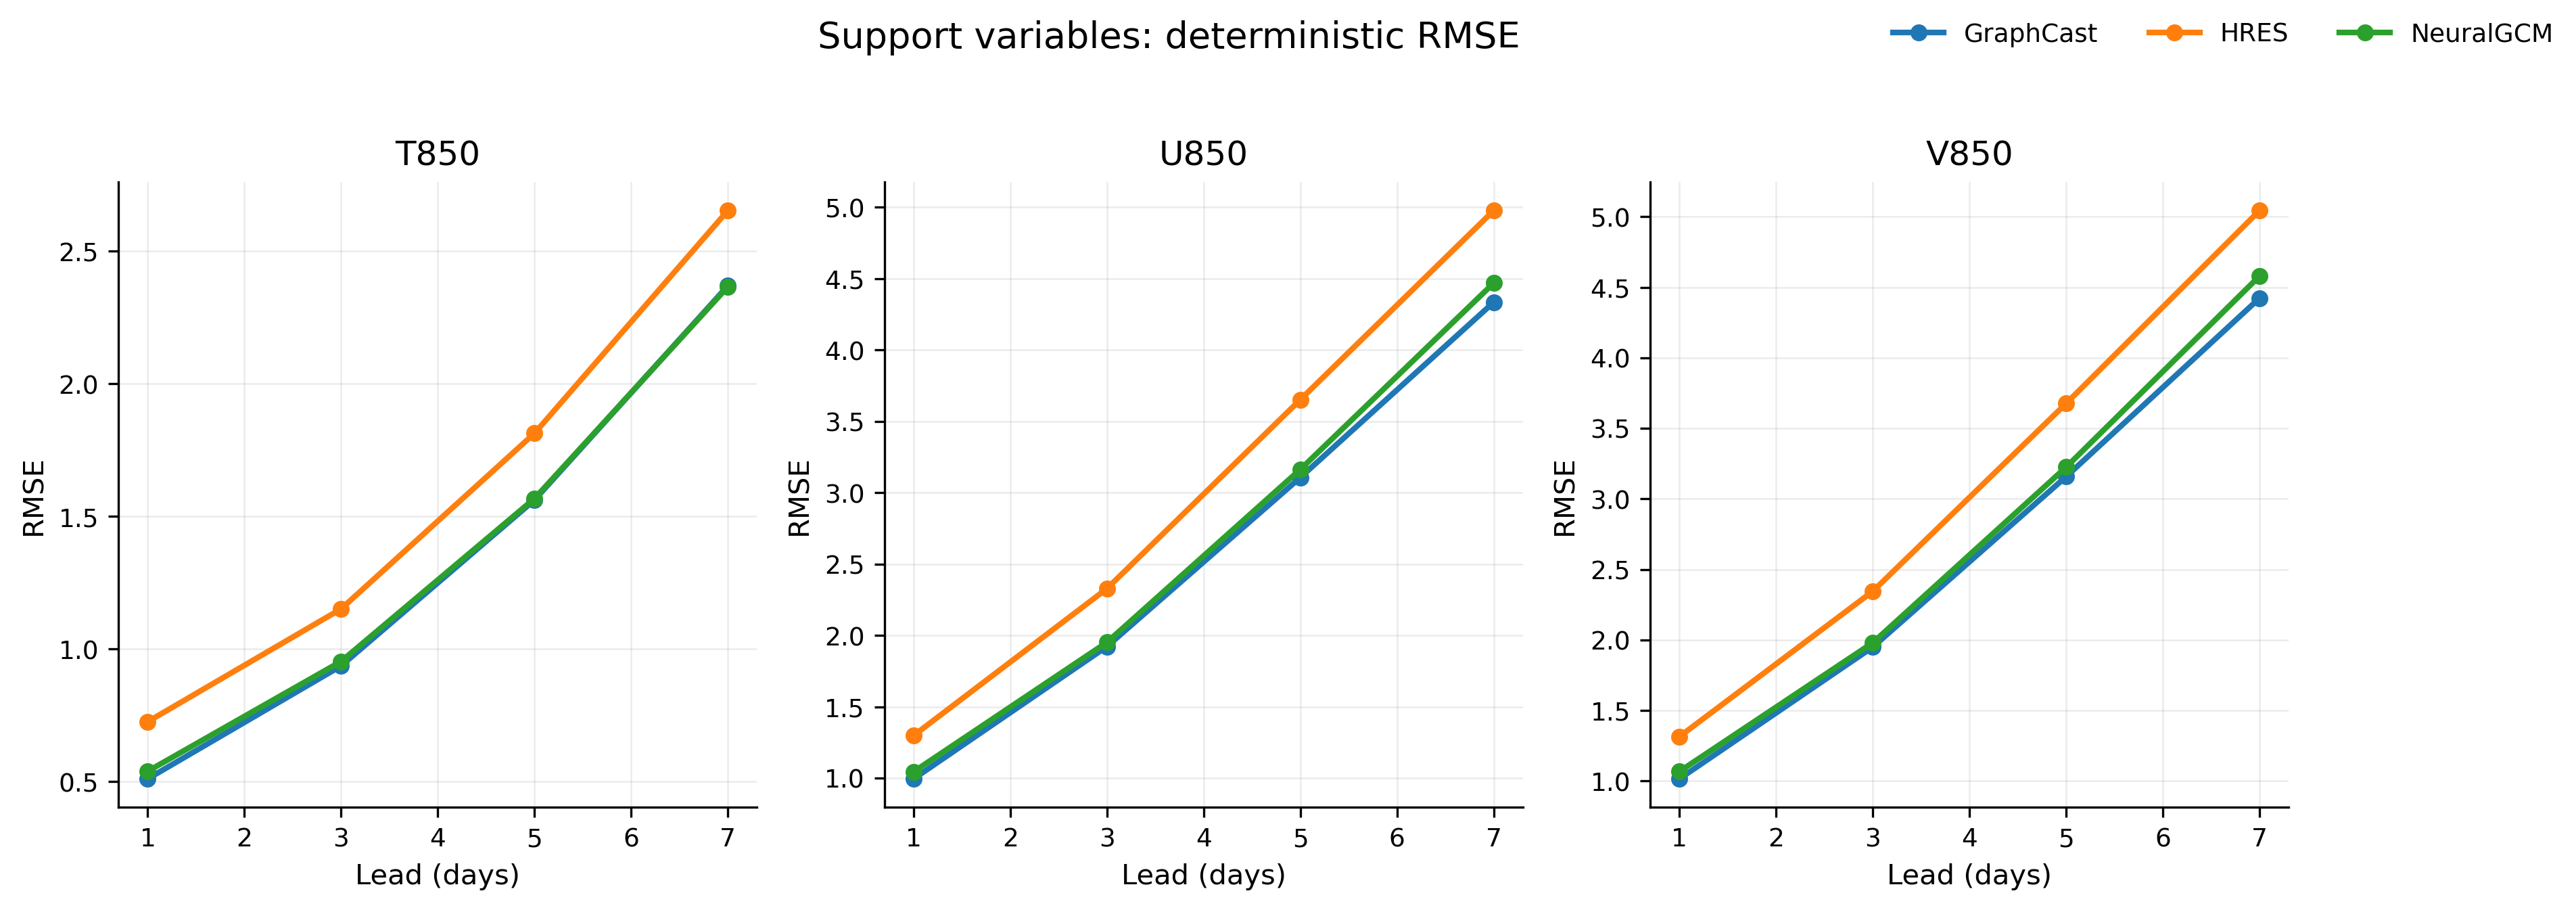

fig03_z500_regime_rmse.png


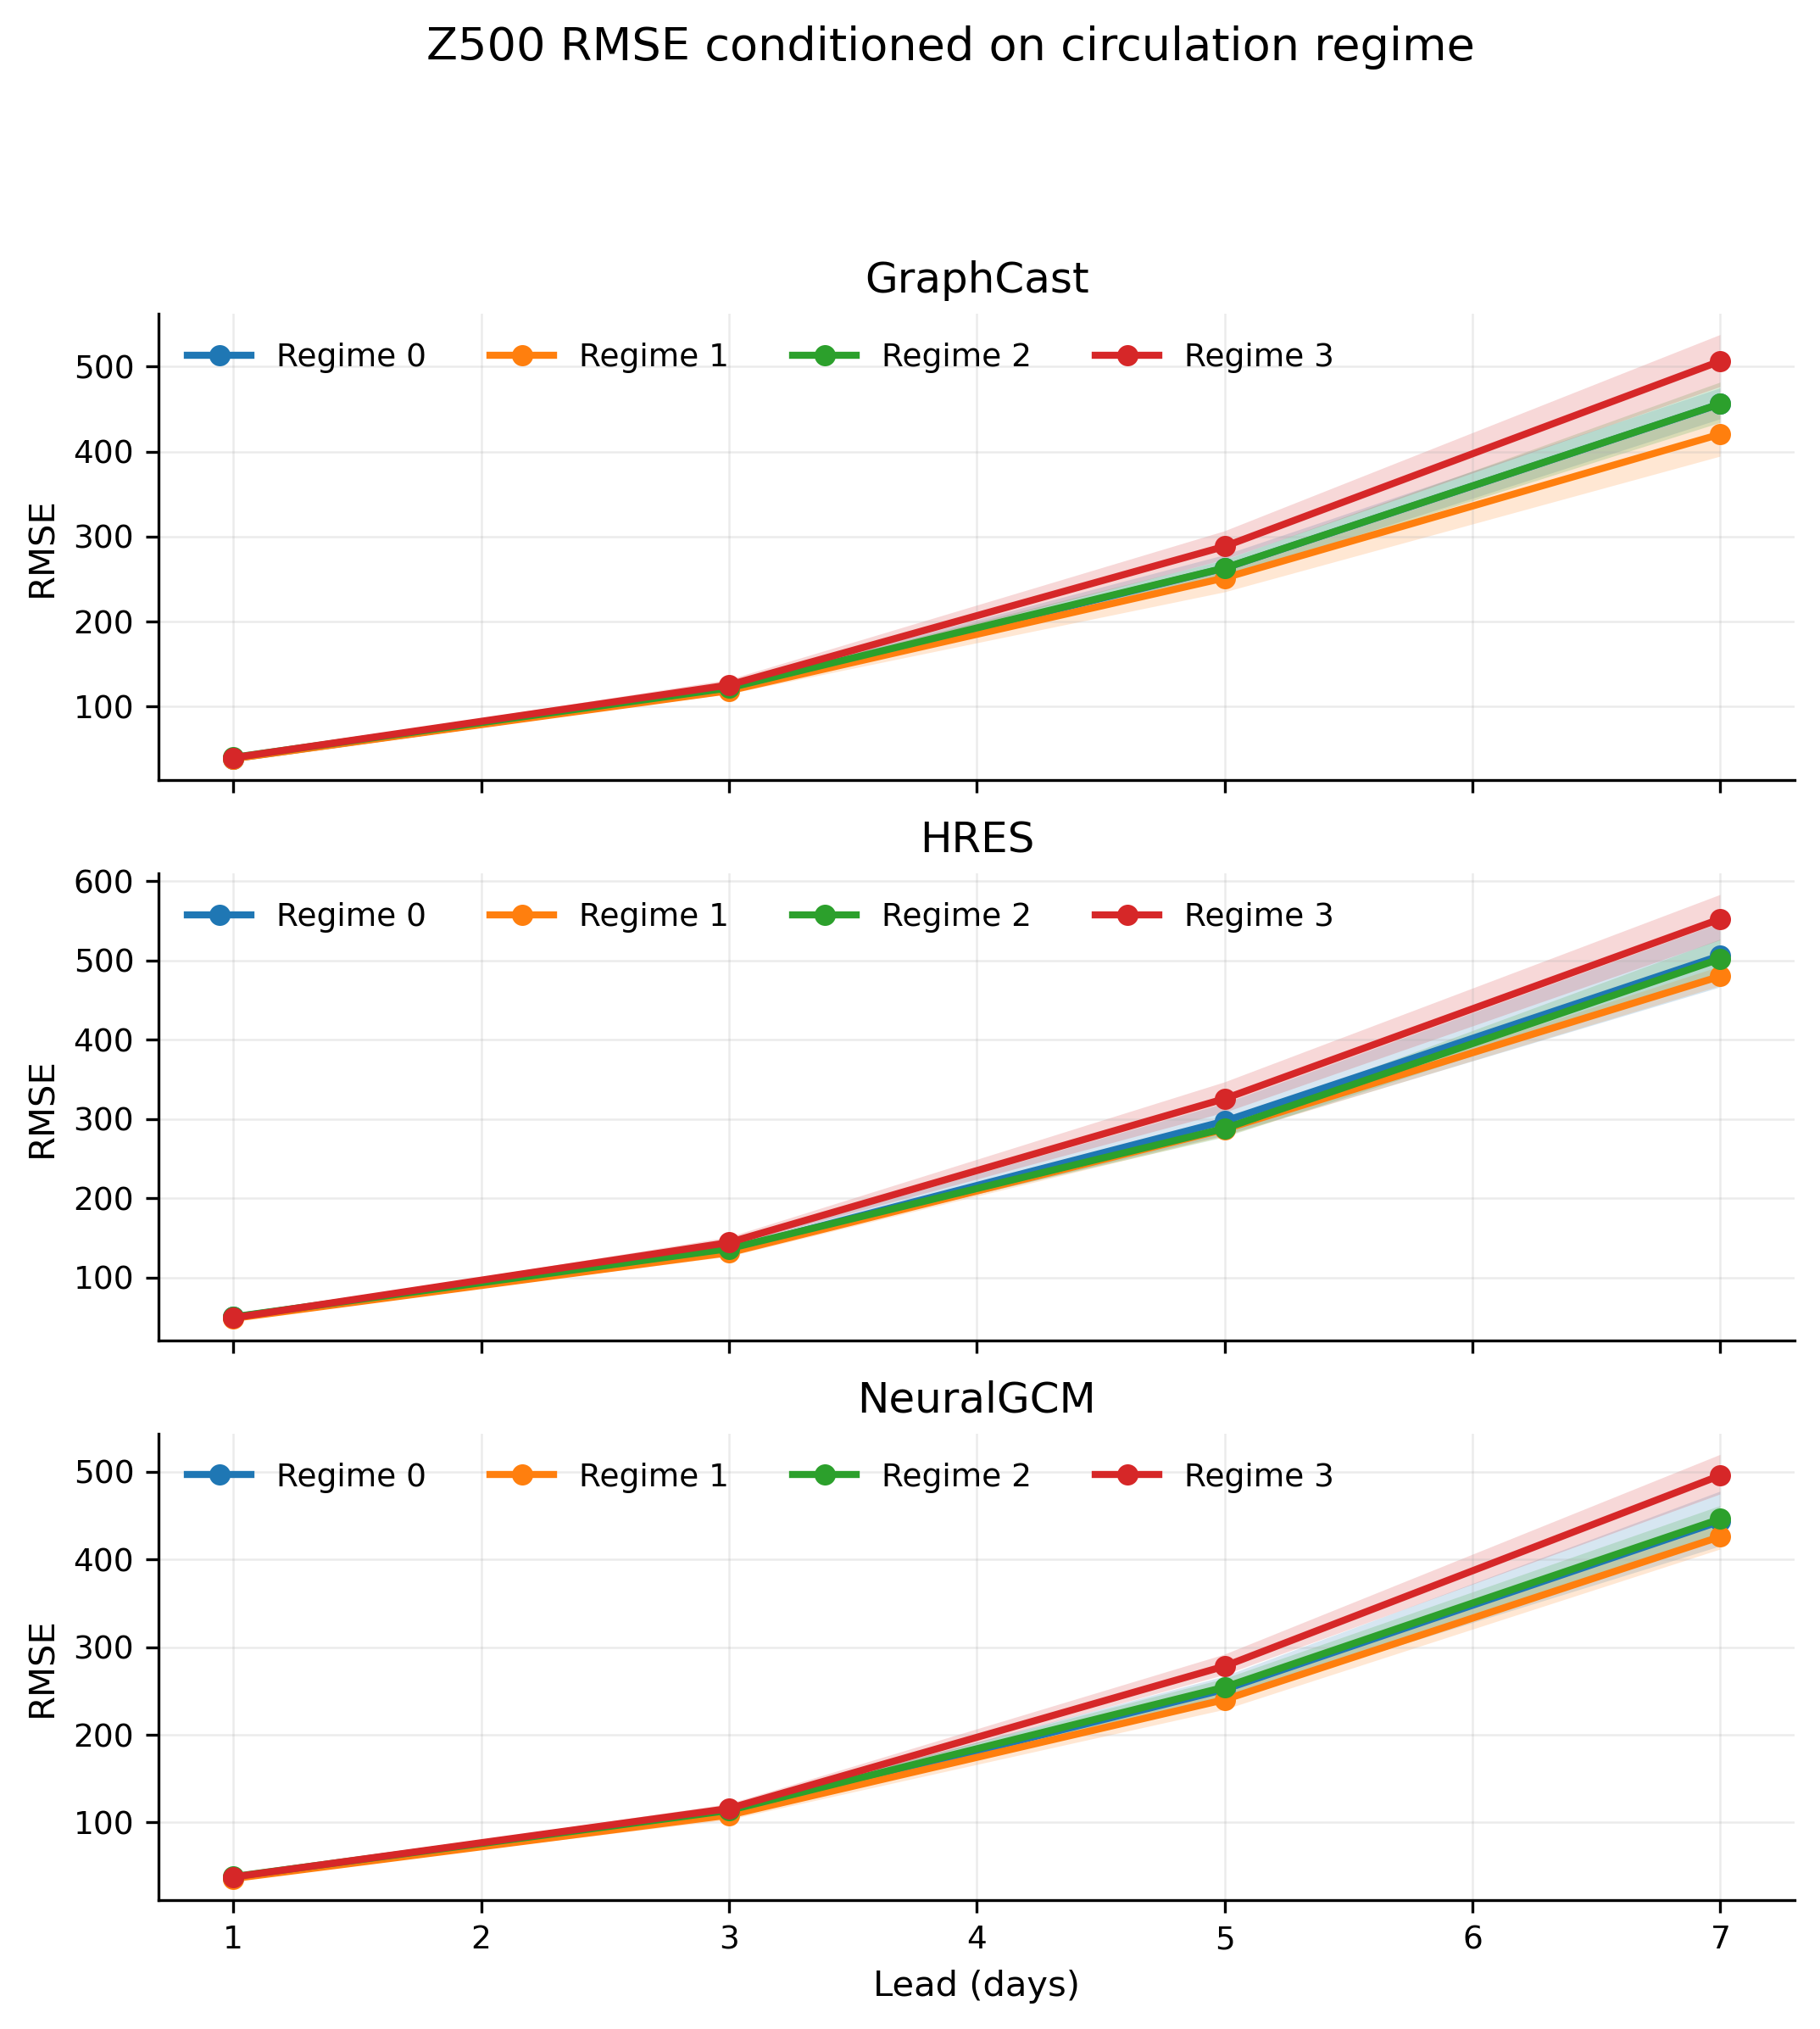

fig04_z500_regime_acc.png


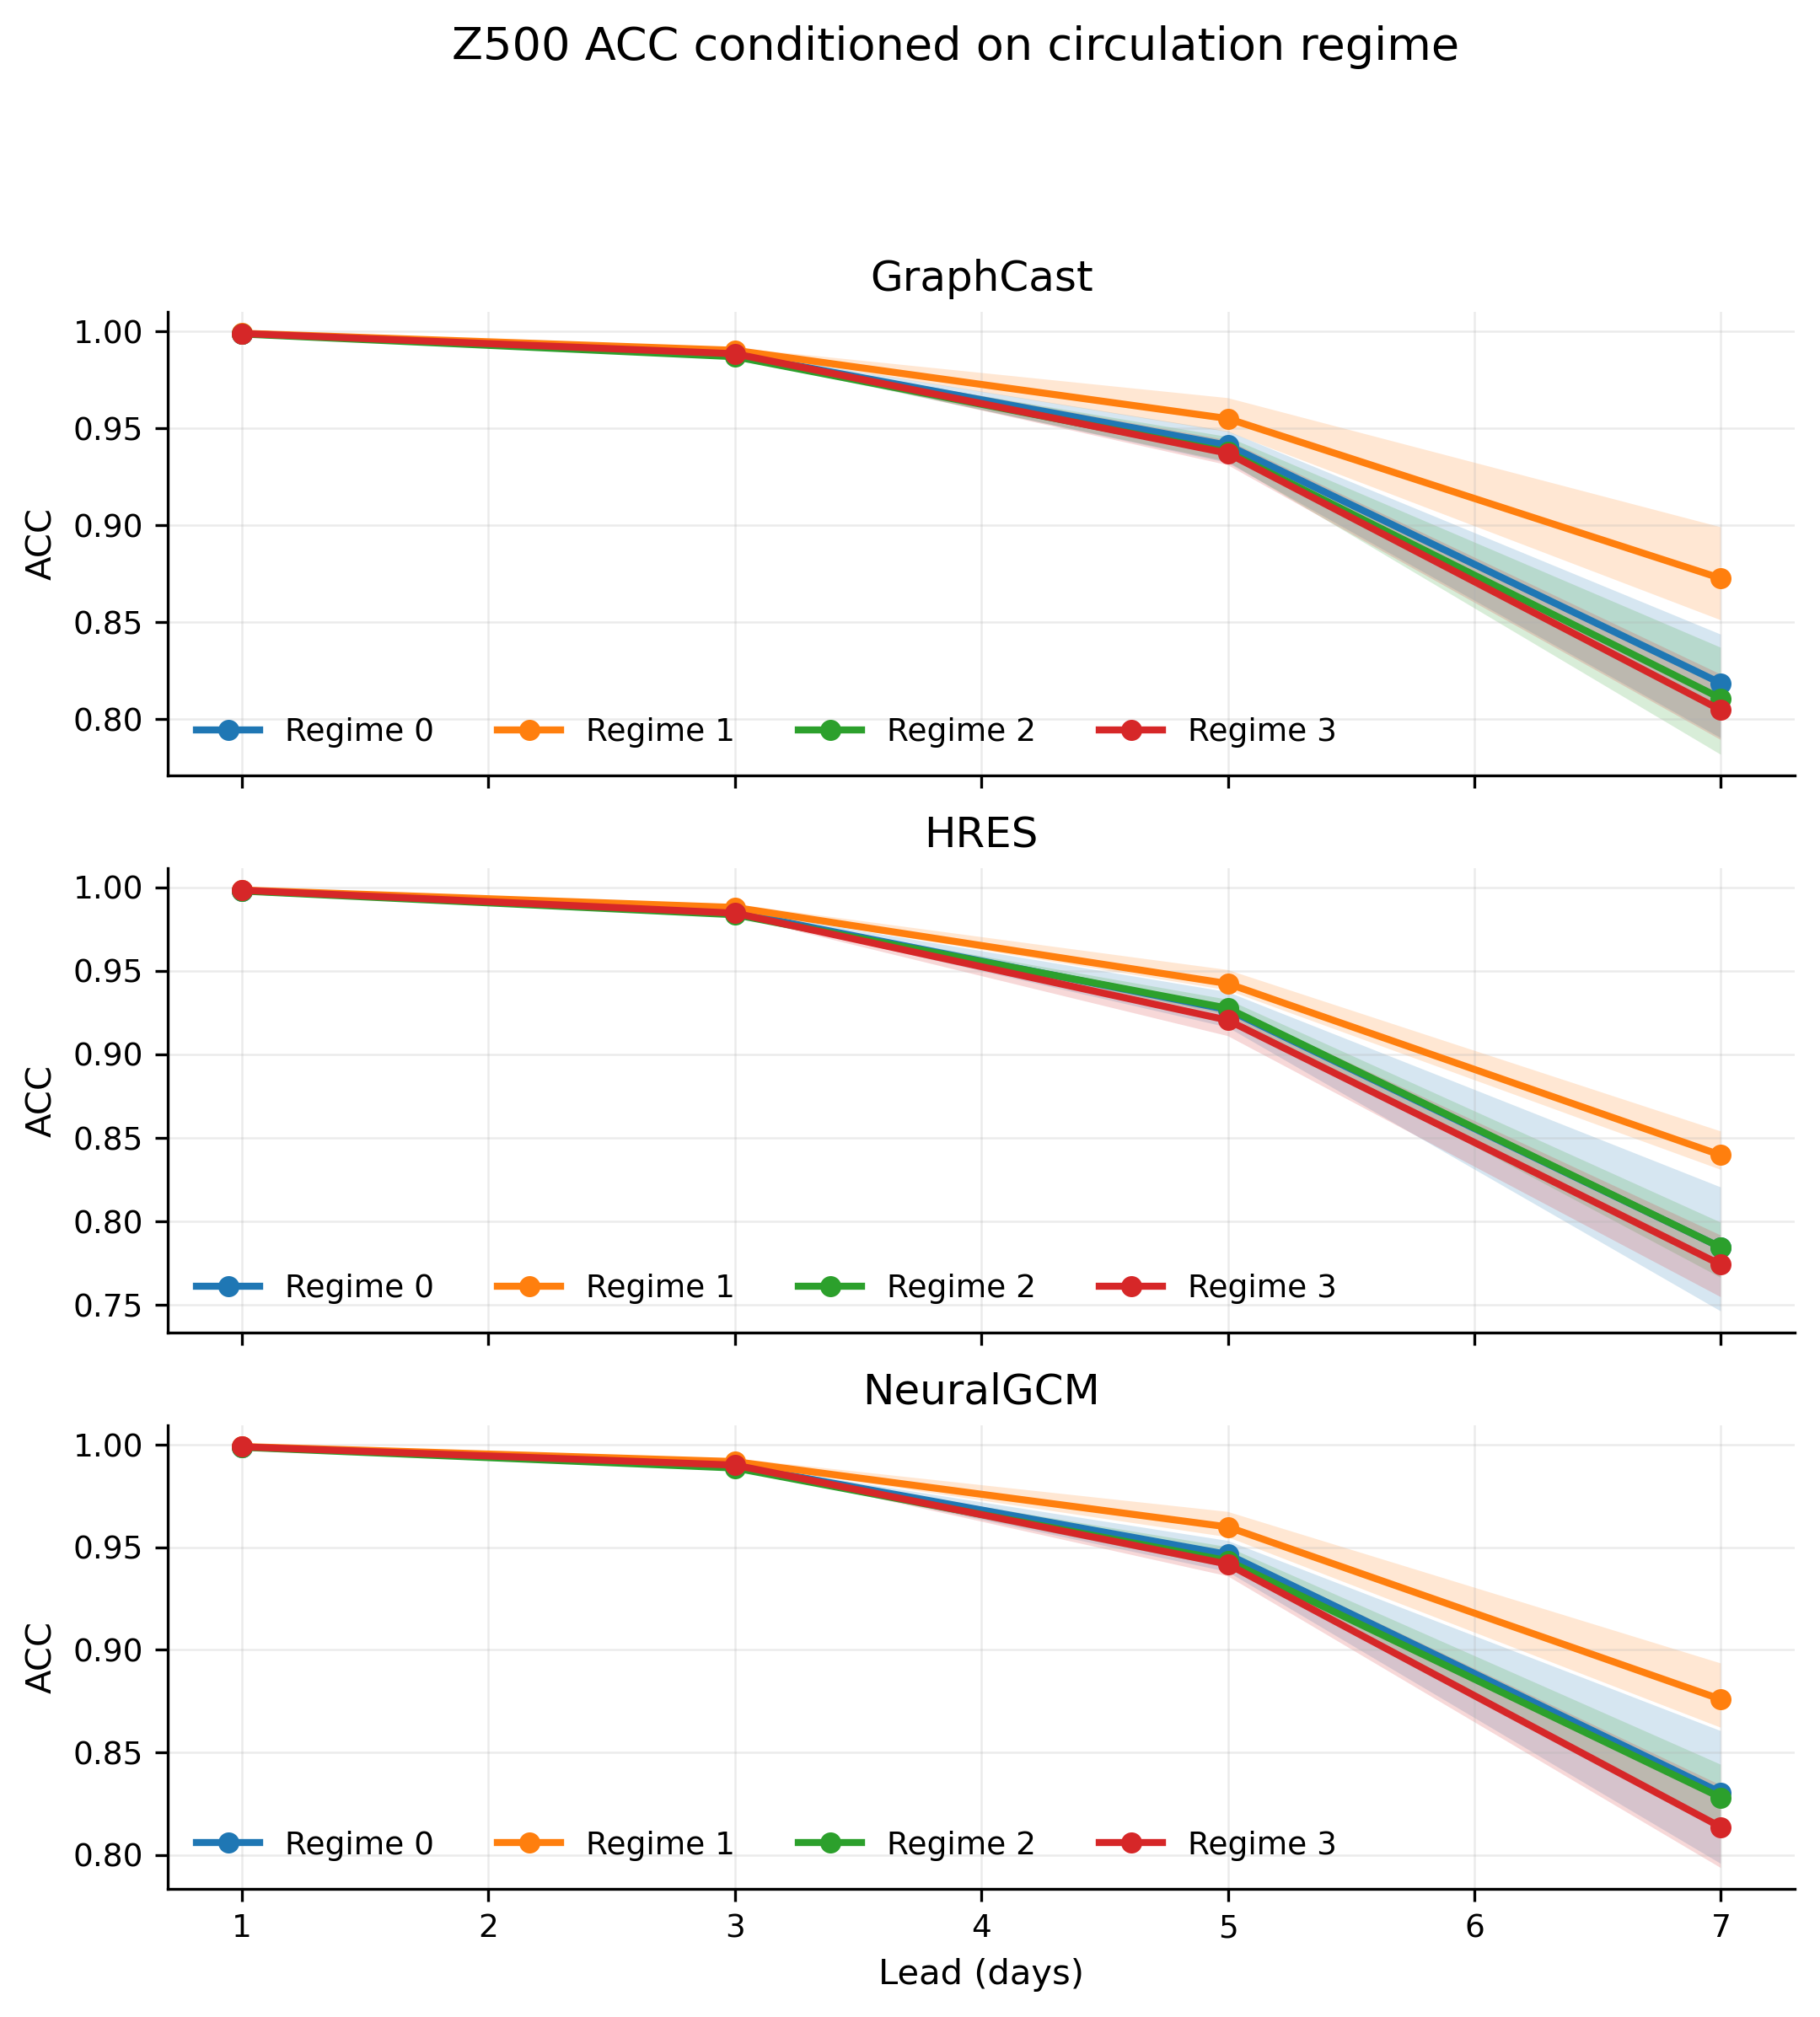

fig05_z500_spectral_summary.png


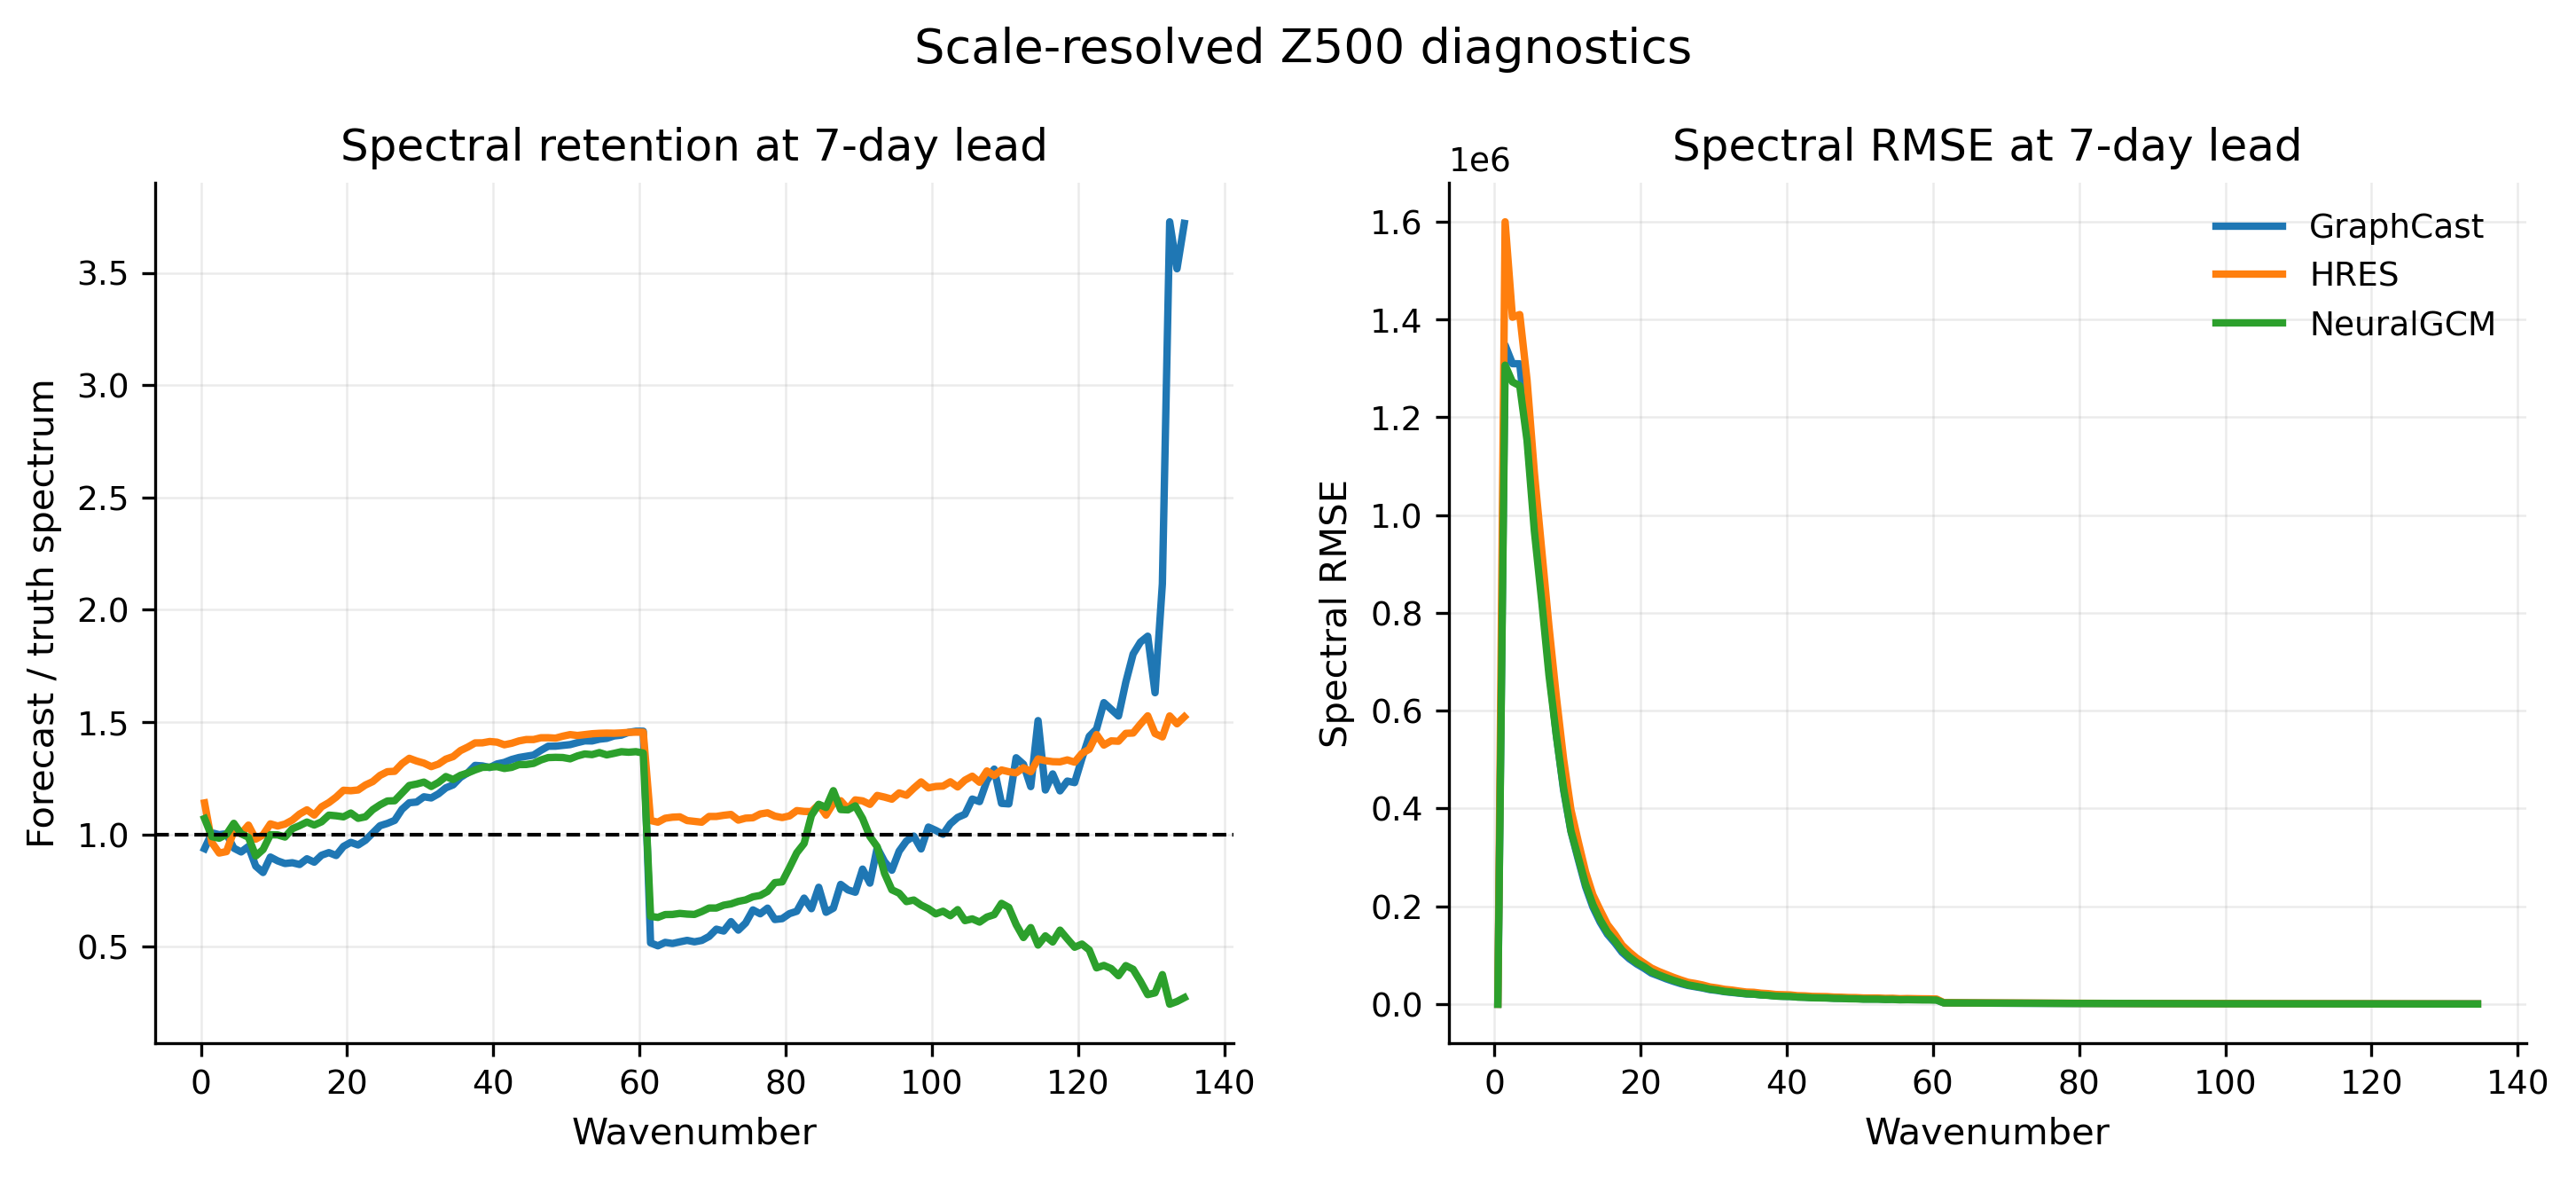

fig06_balance_diagnostics.png


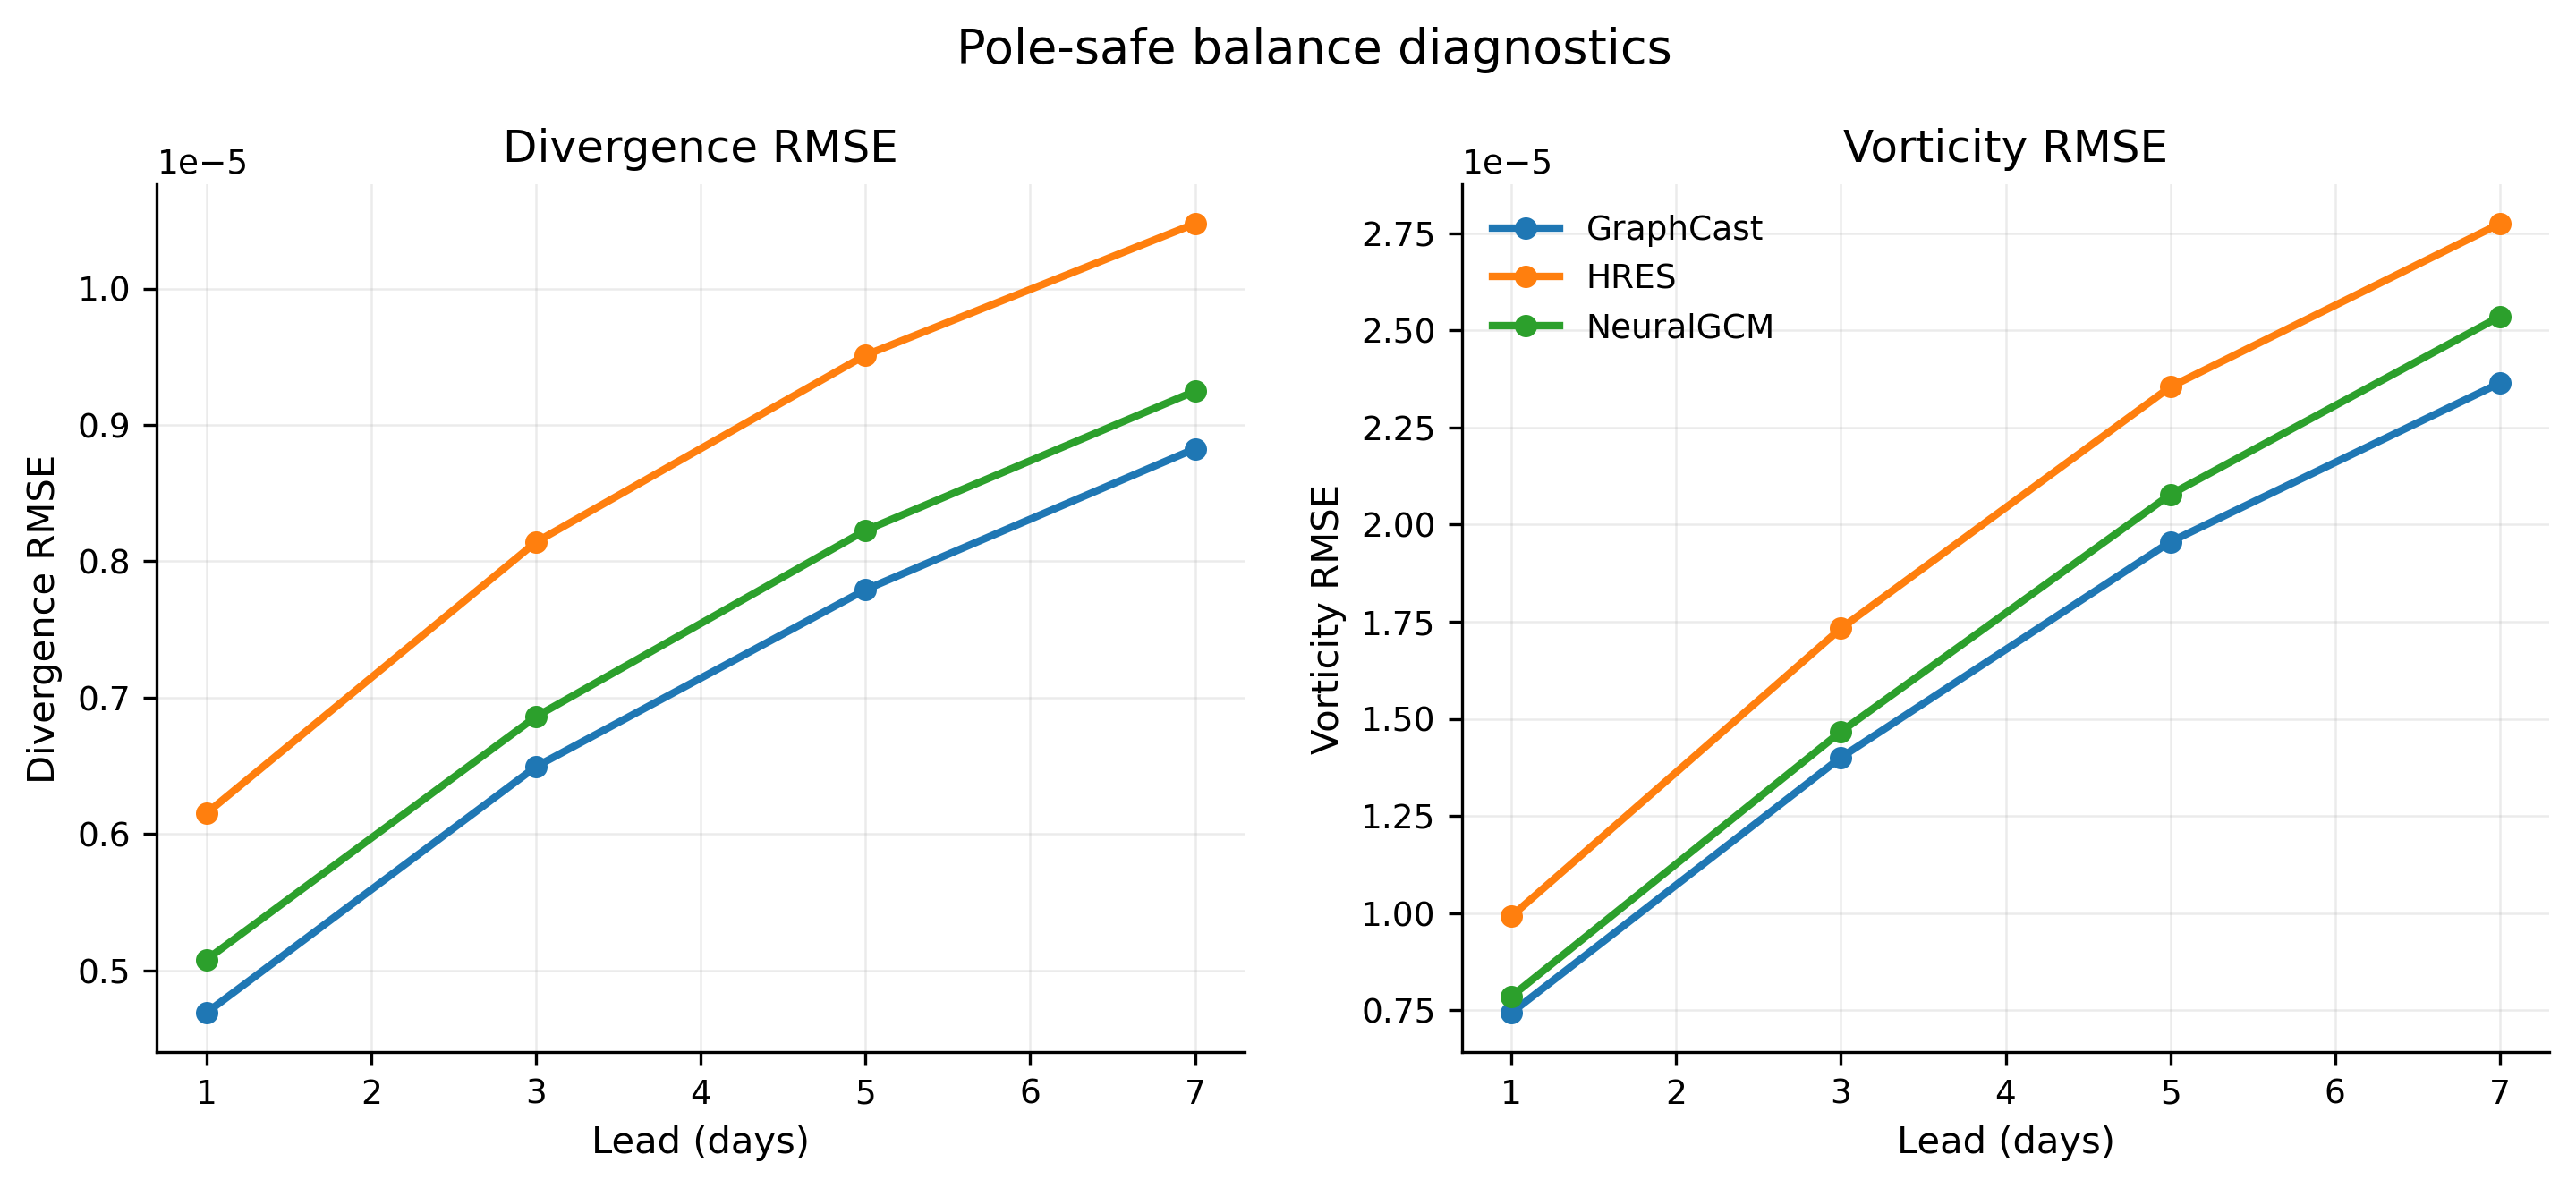

fig07_growth_diagnostics.png


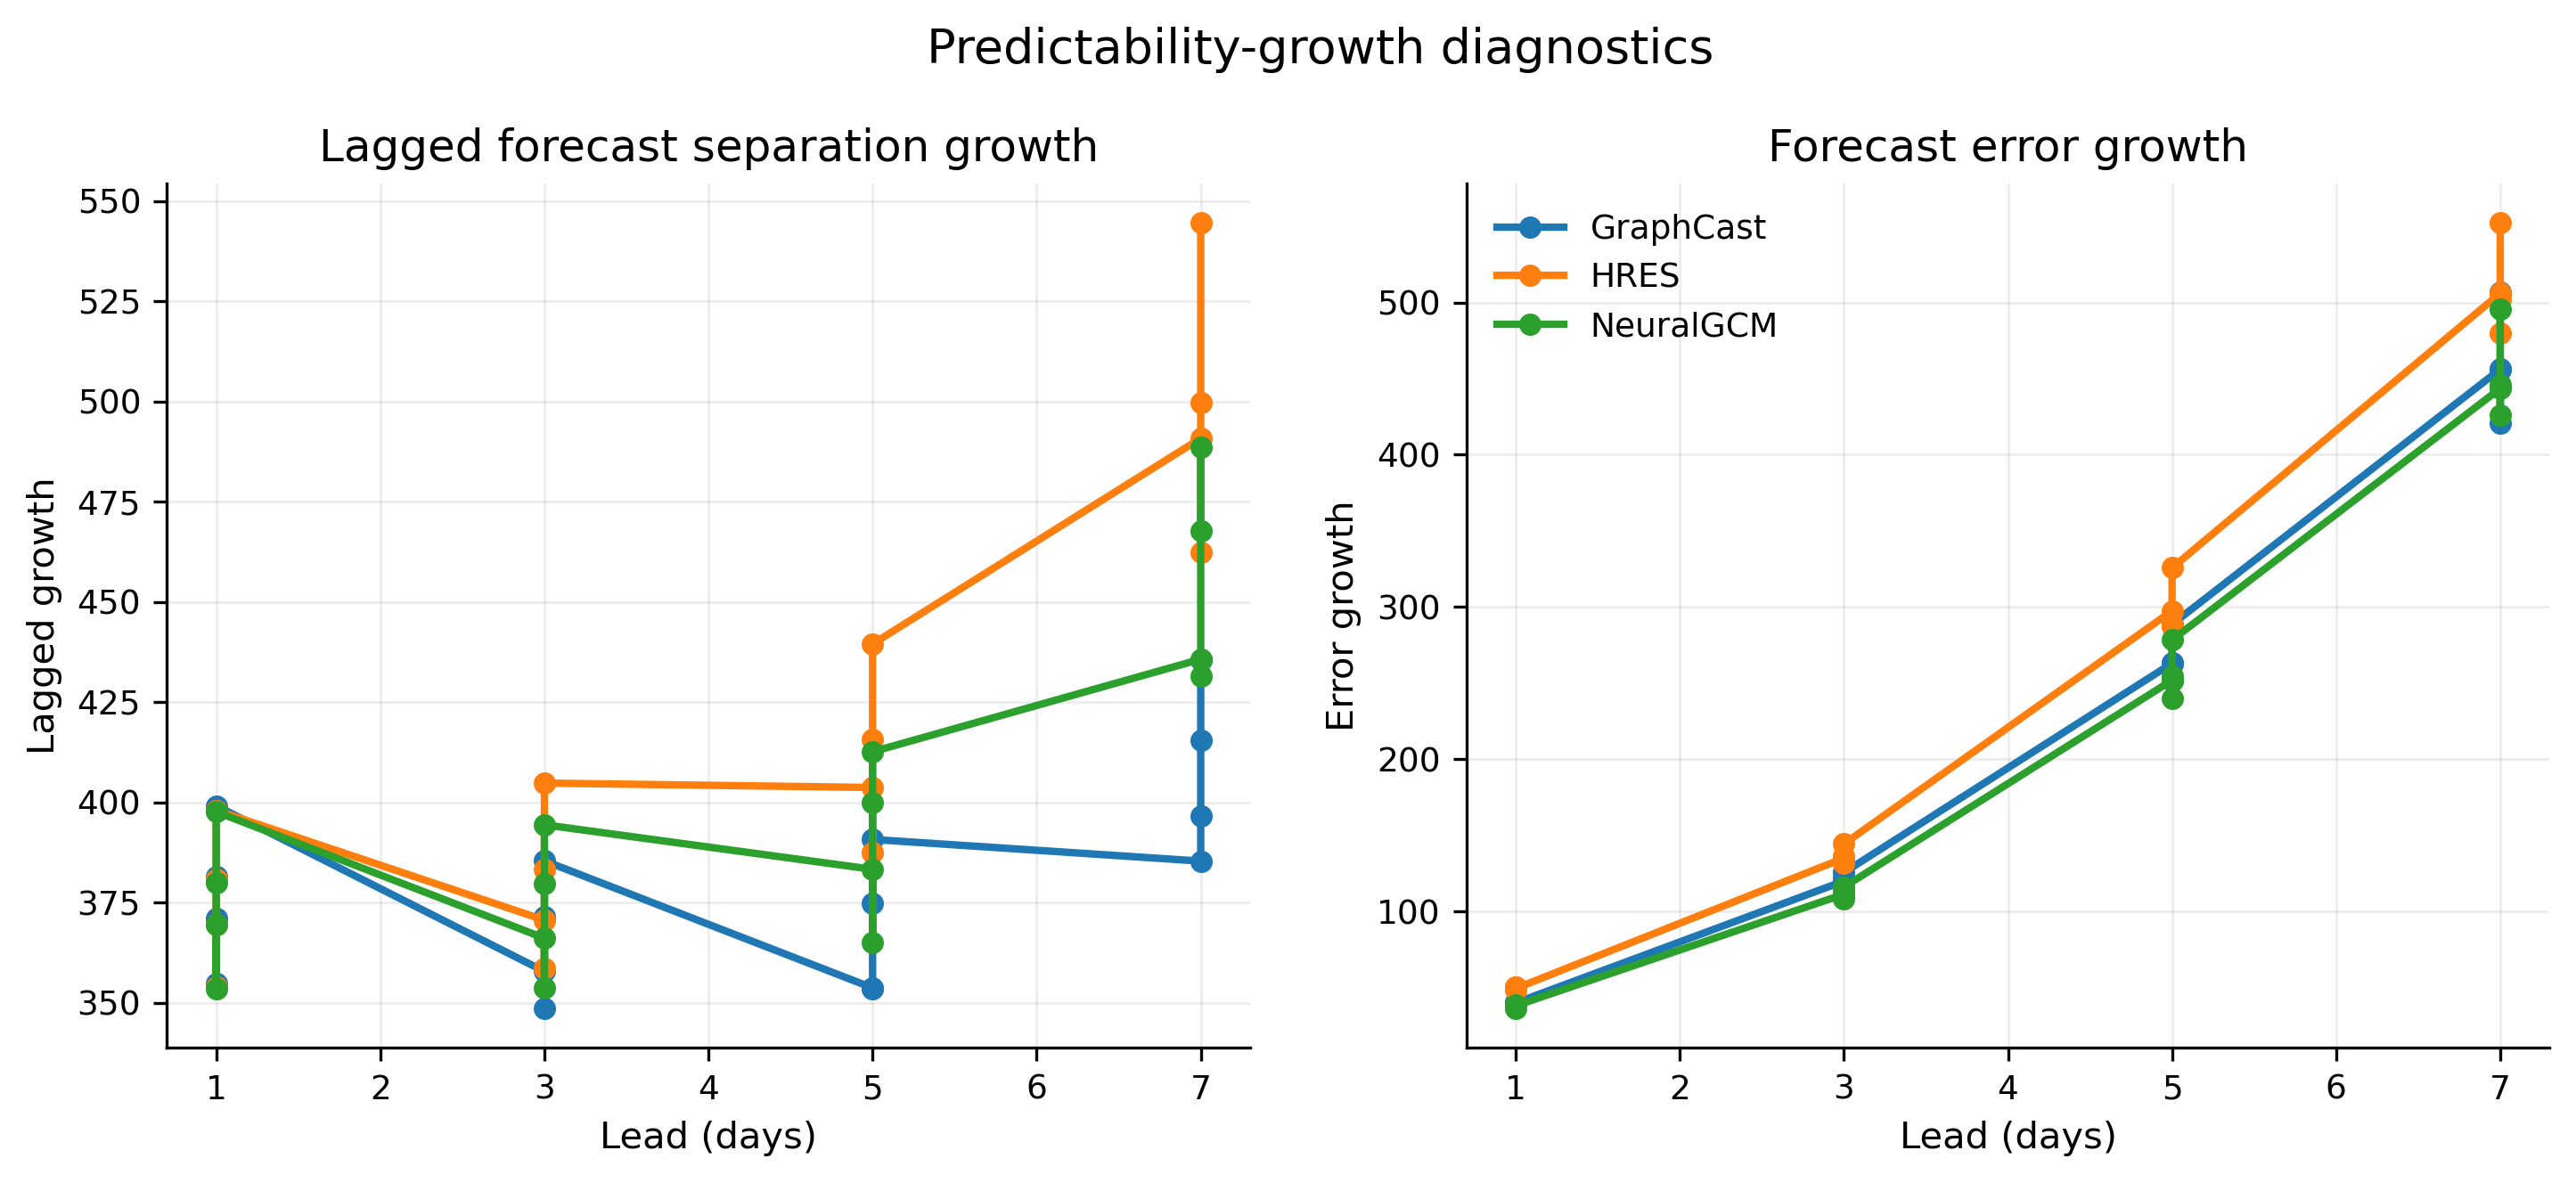

fig08_blocking_summary.png


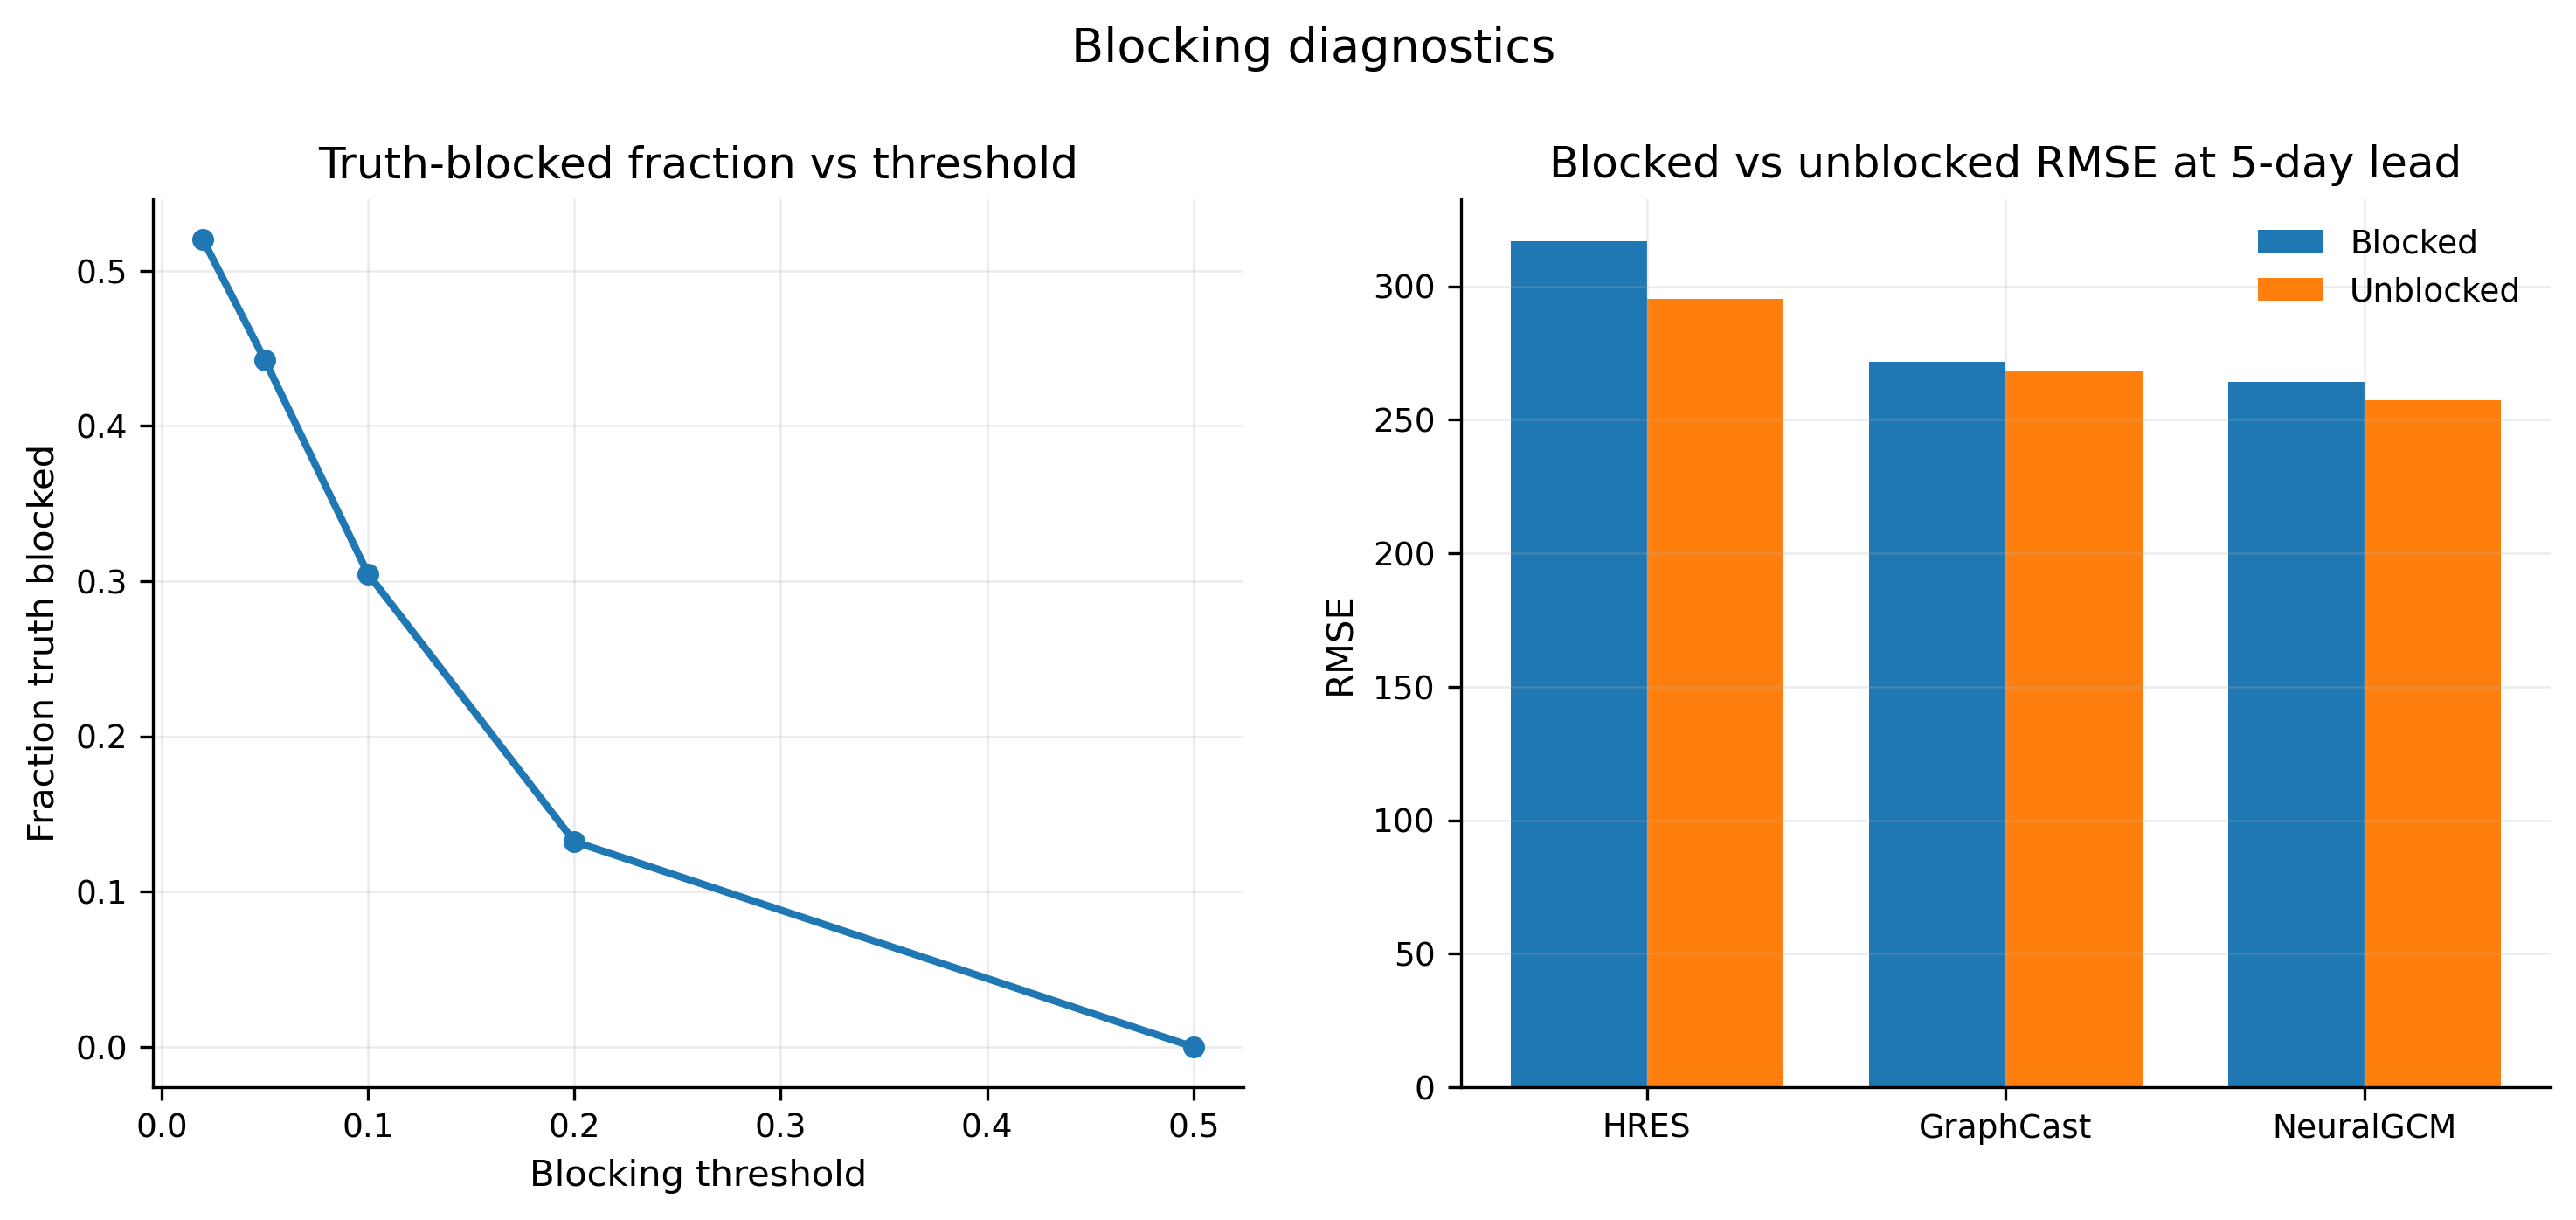

In [6]:

# Optional inline preview of the main paper figures
from IPython.display import Image, display

mani = pd.read_csv(SELECTED_ROOT / "tables" / "selected_figure_manifest.csv")
for stem in mani[mani["tier"] == "main"]["figure_stem"]:
    png = SELECTED_ROOT / "main_figures" / f"{stem}.png"
    if png.exists():
        print(png.name)
        display(Image(filename=str(png), width=850))
